# Appendix C: Review of Calculus

**Source Span.** *Introduction to Smooth Manifolds*, Appendix C, printed pages `642-662`. I inspected the appendix with `pdftotext -layout`, using approximately PDF pages `660-680`, including total derivatives, partial derivatives, chain rule, mixed partials, directional derivatives, differentiation under an integral sign, Taylor theorem with integral remainder, Riemann integration and domains of integration, change of variables, vector-valued integrals and Lipschitz estimates, uniform convergence, the inverse function theorem, and the implicit function theorem.

**Chapter goal.** Turn the appendix from a list of analytic facts into a working toolkit for smooth manifolds: read a total derivative as the best local linear model, interpret Jacobians as coordinate matrices for differentials, see when limits can pass through derivatives and integrals, and recognize the local chart mechanisms behind the inverse and implicit function theorems.

The source is used only for structure, terminology, theorem orientation, and concept coverage. The prose, examples, code, diagrams, and checks below are original.

## Visual Storyboard And Library Routing

| Storyboard item | Representation | Library route | Artifact target | Validation target |
| --- | --- | --- | --- | --- |
| Total derivative | surface with tangent plane plus remainder scaling | SymPy + NumPy + Matplotlib | `figures/total-derivative-tangent-plane.png` | `|R(v)|/|v|` decreases near the base point |
| Partial derivatives and chain rule | Jacobian determinant heatmaps and exact composite check | SymPy + Plotly + Matplotlib | `figures/jacobian-chain-rule-heatmaps.png`, `html/jacobian-chain-rule-heatmaps.html` | symbolic residual of `D(G o F) = DG(F) DF` is zero |
| Mixed partials and directional derivatives | common mixed partial field plus directional scan | SymPy + NumPy + Matplotlib | `figures/mixed-partials-directional-derivatives.png` | C2 mixed partials agree; directional derivative equals gradient dot vector |
| Differentiating integrals and Taylor remainder | exact integral-derivative check and log-log error plot | SymPy + NumPy + Matplotlib | `figures/differentiation-under-integral-and-taylor.png` | integral residual zero; Taylor error stays below sampled cubic bound |
| Riemann integration | lower/upper sums and shrinking boundary tube | NumPy + Matplotlib | `figures/riemann-partitions-domain-boundary.png` | upper-lower gap decreases; boundary tube area tends to zero |
| Change of variables | polar-sector grid with local area distortion | NumPy + Plotly + Matplotlib | `figures/change-of-variables-area-distortion.png`, `html/change-of-variables-area-distortion.html` | cell area ratios match the Jacobian determinant |
| Vector-valued estimates | vector integral norm bound and Lipschitz sample ratios | NumPy + Matplotlib | `figures/vector-integral-and-lipschitz-estimate.png` | `|int F| <= int |F|`; sampled Lipschitz ratios below derivative bound |
| Uniform convergence | good and bad interchange tests | NumPy + Matplotlib | `figures/uniform-convergence-interchange.png` | uniform integral convergence; derivative interchange only under uniform derivative convergence |
| Inverse and implicit theorems | local diffeomorphism grid and level-set graph | SymPy + NumPy + Plotly + Matplotlib | `figures/inverse-implicit-local-charts.png`, `html/inverse-implicit-local-charts.html` | nonzero Jacobian determinant; nonzero implicit partial; level residual small |

Matplotlib is used for durable static diagrams and validation plots. Plotly is used where a rotatable or zoomable map helps inspect a local chart or changing area scale. SymPy supplies exact derivative identities, while NumPy and pandas carry reproducible numeric sweeps and tables.

In [1]:
from __future__ import annotations

import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
from IPython.display import display


def locate_book_root() -> Path:
    start = Path.cwd().resolve()
    candidates = [start, *start.parents, start / "Introduction-to-Smooth-Manifolds"]
    for candidate in candidates:
        if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists() and (candidate / "utils").exists():
            return candidate
    raise RuntimeError("Could not locate Introduction-to-Smooth-Manifolds root")


BOOK_ROOT = locate_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
    save_plotly_html,
)

UNIT_KEY = "appendix-c-review-of-calculus"
SOURCE_SPAN = {
    "printed_pages": "642-662",
    "pdf_pages_inspected": "660-680",
    "pdftotext_command": "pdftotext -f 660 -l 680 -layout 'Introduction to Smooth Manifolds.pdf' -",
}
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
HTML = ARTIFACT_ROOT / "html"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"

generated_artifacts: list[Path] = []
check_paths: list[Path] = []
coverage = {
    "total derivative and best linear approximation": False,
    "partial derivatives, Jacobian, smoothness": False,
    "chain rule": False,
    "mixed partials": False,
    "directional derivatives": False,
    "differentiation under integral sign": False,
    "Taylor theorem with remainder": False,
    "Riemann integration and domains": False,
    "change of variables": False,
    "vector-valued integrals and estimates": False,
    "uniform convergence interchange": False,
    "inverse function theorem": False,
    "implicit function theorem": False,
}


def rel(path: Path) -> str:
    return Path(path).resolve().relative_to(BOOK_ROOT.resolve()).as_posix()


def record_artifact(path: Path) -> Path:
    generated_artifacts.append(Path(path))
    return Path(path)


def record_check(path: Path) -> Path:
    check_paths.append(Path(path))
    return Path(path)


np.set_printoptions(precision=5, suppress=True)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {rel(ARTIFACT_ROOT)}")

Book root: D:\Geometry\Introduction-to-Smooth-Manifolds
Artifact root: artifacts/appendix-c-review-of-calculus


In [2]:
routing_rows = [
    {"concept": "total derivative", "representation": "surface, tangent plane, scaled remainder", "library": "SymPy + NumPy + Matplotlib", "why": "exact gradient builds the linear map; the plot exposes best linear approximation"},
    {"concept": "Jacobian and chain rule", "representation": "determinant heatmaps and exact matrix identity", "library": "SymPy + Plotly + Matplotlib", "why": "symbolic matrices prove the identity while heatmaps show local area scale"},
    {"concept": "mixed partials and directional derivatives", "representation": "common second-partial field and direction scan", "library": "SymPy + NumPy + Matplotlib", "why": "exact derivatives plus sampled directions separate theorem from computation"},
    {"concept": "integral differentiation and Taylor", "representation": "exact interchange check and cubic remainder plot", "library": "SymPy + NumPy + Matplotlib", "why": "theorems are about controlled remainders and moving limits through integrals"},
    {"concept": "Riemann integration domains", "representation": "upper-lower partitions and boundary tube", "library": "NumPy + Matplotlib", "why": "partitions and measure-zero boundary are geometric estimates"},
    {"concept": "change of variables", "representation": "polar-sector grid with Jacobian coloring", "library": "NumPy + Plotly + Matplotlib", "why": "area distortion is local and benefits from zoomable grid inspection"},
    {"concept": "vector integrals and estimates", "representation": "integral vector, norm bound, Lipschitz ratios", "library": "NumPy + Matplotlib", "why": "the vector inequality and derivative estimate are numerical norm statements"},
    {"concept": "uniform convergence", "representation": "sup-norm, integral, and derivative-error sweeps", "library": "NumPy + Matplotlib", "why": "the distinction between function convergence and derivative convergence is a sequence diagnostic"},
    {"concept": "inverse and implicit functions", "representation": "local chart grid and level graph", "library": "SymPy + NumPy + Plotly + Matplotlib", "why": "nonzero derivative hypotheses become visible local coordinate tests"},
]

storyboard_rows = [
    {"order": 1, "artifact": "figures/total-derivative-tangent-plane.png", "inspection_target": "compare surface, tangent plane, and first-order remainder", "validation": "scaled remainder tends to zero"},
    {"order": 2, "artifact": "figures/jacobian-chain-rule-heatmaps.png", "inspection_target": "read local determinant scales before and after composition", "validation": "symbolic chain-rule residual zero"},
    {"order": 3, "artifact": "figures/mixed-partials-directional-derivatives.png", "inspection_target": "compare mixed partial equality with gradient directional action", "validation": "exact equality for smooth example"},
    {"order": 4, "artifact": "figures/differentiation-under-integral-and-taylor.png", "inspection_target": "watch integral differentiation and cubic Taylor error", "validation": "interchange residual zero and error below bound"},
    {"order": 5, "artifact": "figures/riemann-partitions-domain-boundary.png", "inspection_target": "see partitions squeeze an integral and boundary tubes shrink", "validation": "upper-lower gap decreases"},
    {"order": 6, "artifact": "figures/change-of-variables-area-distortion.png", "inspection_target": "match polar cell areas to the factor r", "validation": "polygon-cell area ratios match determinant"},
    {"order": 7, "artifact": "figures/vector-integral-and-lipschitz-estimate.png", "inspection_target": "compare the vector integral with integral of lengths", "validation": "norm and Lipschitz inequalities hold"},
    {"order": 8, "artifact": "figures/uniform-convergence-interchange.png", "inspection_target": "separate uniform function convergence from derivative convergence", "validation": "good case converges, oscillatory derivative does not"},
    {"order": 9, "artifact": "figures/inverse-implicit-local-charts.png", "inspection_target": "read local diffeomorphism and graph hypotheses from derivatives", "validation": "determinant and implicit y-partial bounded away from zero"},
]

routing_path = record_artifact(save_csv(routing_rows, TABLES / "library-routing.csv"))
storyboard_path = record_artifact(save_csv(storyboard_rows, TABLES / "visual-storyboard.csv"))
storyboard_json_path = record_check(save_json({"source_span": SOURCE_SPAN, "routing": routing_rows, "storyboard": storyboard_rows}, CHECKS / "visual-storyboard.json"))
assert_artifacts([routing_path, storyboard_path, storyboard_json_path], min_bytes=120)
display(pd.DataFrame(routing_rows))
display_artifact(storyboard_path)
print(f"Saved routing and storyboard under {rel(ARTIFACT_ROOT)}")

,concept,representation,library,why
0,total derivative,"surface, tangent plane, scaled remainder",SymPy + NumPy + Matplotlib,exact gradient builds the linear map; the plot...
1,Jacobian and chain rule,determinant heatmaps and exact matrix identity,SymPy + Plotly + Matplotlib,symbolic matrices prove the identity while hea...
2,mixed partials and directional derivatives,common second-partial field and direction scan,SymPy + NumPy + Matplotlib,exact derivatives plus sampled directions sepa...
3,integral differentiation and Taylor,exact interchange check and cubic remainder plot,SymPy + NumPy + Matplotlib,theorems are about controlled remainders and m...
4,Riemann integration domains,upper-lower partitions and boundary tube,NumPy + Matplotlib,partitions and measure-zero boundary are geome...
5,change of variables,polar-sector grid with Jacobian coloring,NumPy + Plotly + Matplotlib,area distortion is local and benefits from zoo...
6,vector integrals and estimates,"integral vector, norm bound, Lipschitz ratios",NumPy + Matplotlib,the vector inequality and derivative estimate ...
7,uniform convergence,"sup-norm, integral, and derivative-error sweeps",NumPy + Matplotlib,the distinction between function convergence a...
8,inverse and implicit functions,local chart grid and level graph,SymPy + NumPy + Plotly + Matplotlib,nonzero derivative hypotheses become visible l...


[visual-storyboard.csv](D:/Geometry/Introduction-to-Smooth-Manifolds/artifacts/appendix-c-review-of-calculus/tables/visual-storyboard.csv)

Saved routing and storyboard under artifacts/appendix-c-review-of-calculus


## Computational Translation Guide

| Appendix C idea | Computational representation | What to inspect |
| --- | --- | --- |
| Total derivative | a matrix or linear map `DF(a)` plus a remainder `R(v)` | the quotient `|R(v)|/|v|` tends to zero |
| Partial derivatives | entries of the Jacobian matrix | the Jacobian is the coordinate matrix of the total derivative when differentiability holds |
| Smoothness | all partial derivatives exist and vary continuously to every order needed | symbolic expressions and heatmaps have no jumps on the open region being used |
| Chain rule | matrix product `JG(F(x)) @ JF(x)` | composition multiplies local linear approximations |
| Directional derivative | `grad f(a) dot v` for scalar `f` in Euclidean coordinates | the direction vector need not have unit length |
| Mixed partial theorem | equality of second partials under a `C^2` hypothesis | dropping continuity can break the equality |
| Integral tools | Riemann sums, domains of integration, and limit interchanges | boundaries of measure zero do not affect volume integrals |
| Change of variables | `f(G(u)) * abs(det DG(u))` | the determinant is the infinitesimal volume scale |
| Inverse/implicit theorems | nonzero determinant or nonsingular block partial | a nonlinear map behaves like its derivative on a small enough neighborhood |

## 1. Total Derivative: Best Linear Approximation

For a scalar function of two variables, the total derivative at a point is the linear form given by the gradient. Its graph is the tangent plane. The theorem is not just that the tangent plane touches the surface; it says the leftover error is smaller than first order:

`f(a + v) = f(a) + Df(a)v + R(v)` with `|R(v)|/|v| -> 0`.

The left panel lets you compare the nonlinear surface with its tangent plane. The right panel turns the definition into a numerical diagnostic.

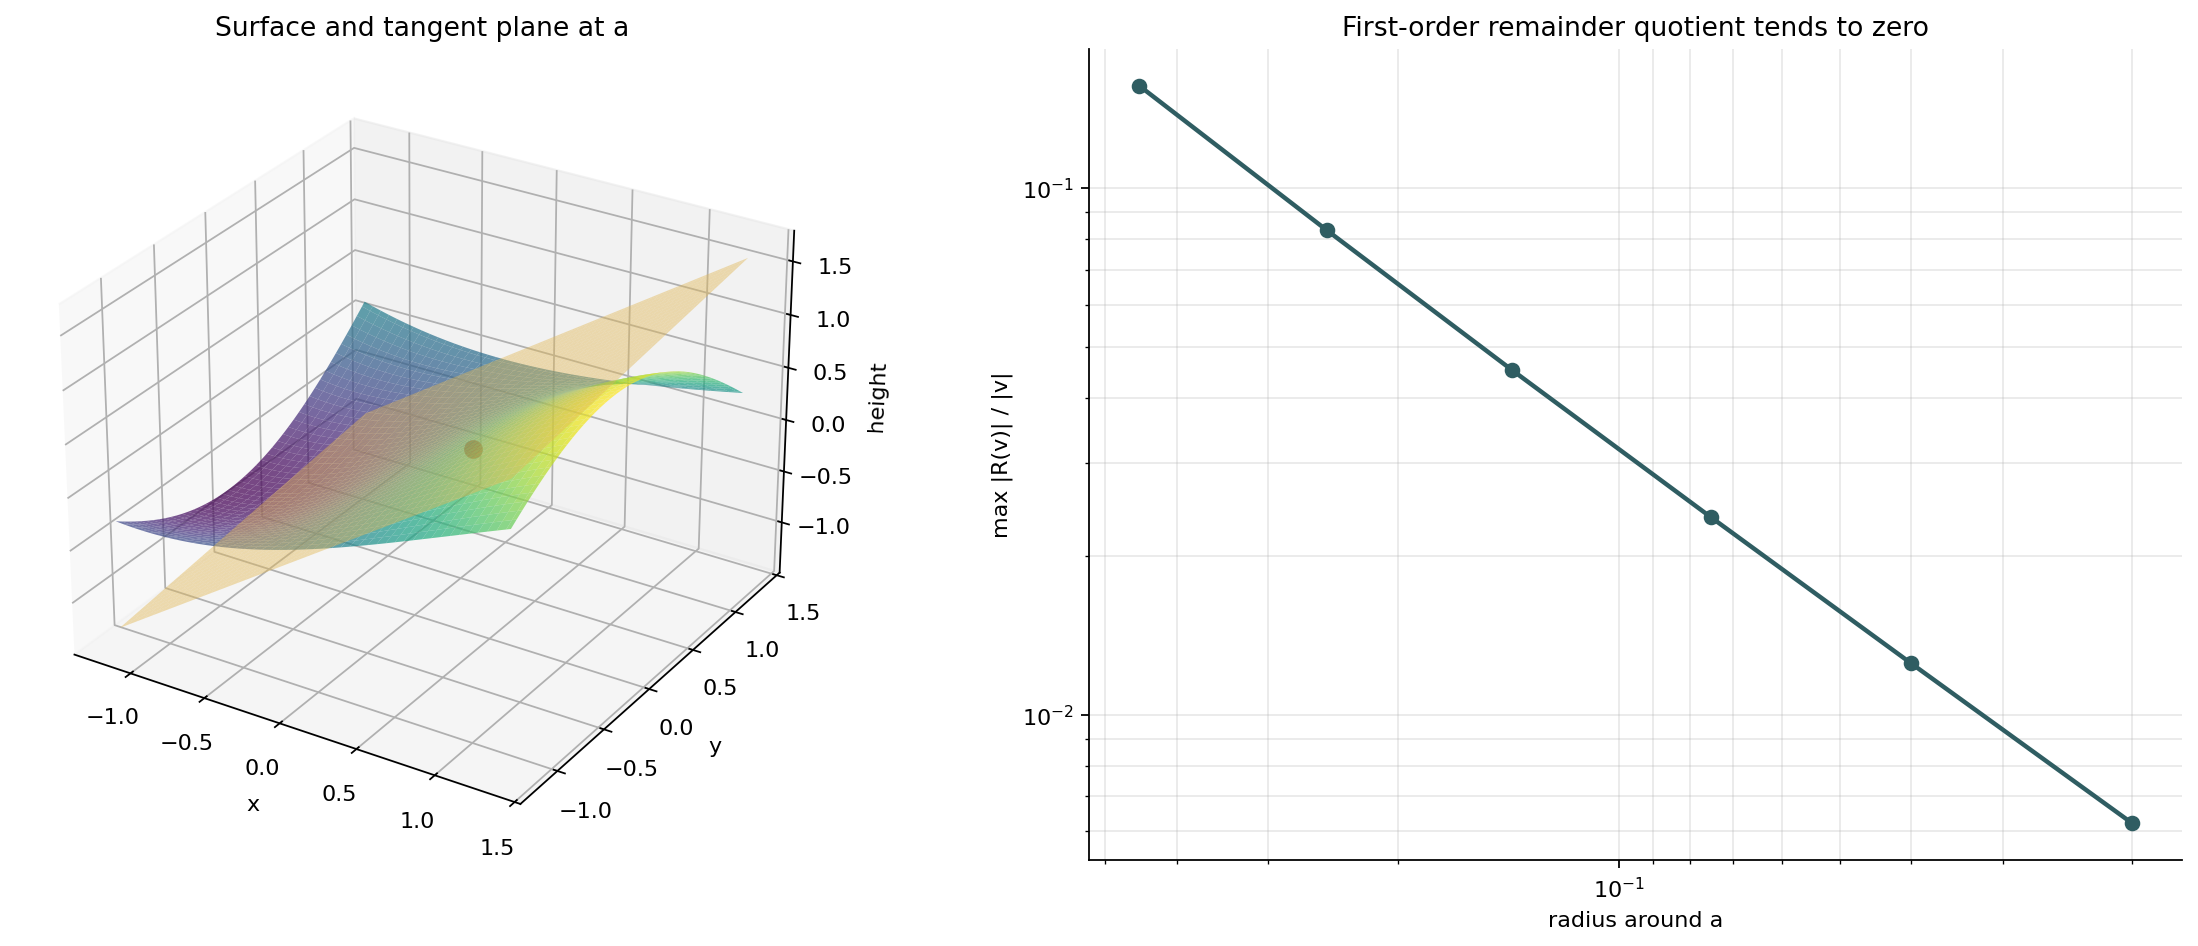

,radius,max_abs_remainder_over_radius
0,0.450,0.156598
1,0.250,0.083248
2,0.140,0.045196
3,0.075,0.023725
4,0.040,0.012507
5,0.020,0.006212


In [3]:
x, y = sp.symbols("x y", real=True)
f_expr = sp.sin(x) * sp.cos(y) + sp.Rational(3, 20) * x**2 - sp.Rational(1, 10) * x * y
a_vec = np.array([0.6, -0.35])
grad_expr = [sp.diff(f_expr, x), sp.diff(f_expr, y)]
f = sp.lambdify((x, y), f_expr, "numpy")
grad_f = [sp.lambdify((x, y), g, "numpy") for g in grad_expr]
f_a = float(f(*a_vec))
grad_a = np.array([float(g(*a_vec)) for g in grad_f])

grid = np.linspace(-1.2, 1.35, 90)
X, Y = np.meshgrid(grid, grid)
Z = f(X, Y)
T = f_a + grad_a[0] * (X - a_vec[0]) + grad_a[1] * (Y - a_vec[1])

theta = np.linspace(0, 2 * np.pi, 240, endpoint=False)
radii = np.array([0.45, 0.25, 0.14, 0.075, 0.04, 0.02])
max_scaled_remainder = []
for radius in radii:
    pts = a_vec[:, None] + radius * np.vstack([np.cos(theta), np.sin(theta)])
    nonlinear = f(pts[0], pts[1])
    linear = f_a + grad_a @ (pts - a_vec[:, None])
    max_scaled_remainder.append(float(np.max(np.abs(nonlinear - linear)) / radius))

fig = plt.figure(figsize=(14.5, 5.8), constrained_layout=True)
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.plot_surface(X, Y, Z, cmap="viridis", alpha=0.72, linewidth=0, antialiased=True)
ax.plot_surface(X, Y, T, color="#f6c85f", alpha=0.46, linewidth=0)
ax.scatter([a_vec[0]], [a_vec[1]], [f_a], color="#c0392b", s=55)
ax.set_title("Surface and tangent plane at a")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("height")
ax.view_init(elev=28, azim=-58)

ax2 = fig.add_subplot(1, 2, 2)
ax2.loglog(radii, max_scaled_remainder, marker="o", color="#2f5d62", lw=2)
ax2.invert_xaxis()
ax2.set_xlabel("radius around a")
ax2.set_ylabel("max |R(v)| / |v|")
ax2.set_title("First-order remainder quotient tends to zero")
ax2.grid(True, which="both", alpha=0.28)

total_derivative_path = record_artifact(save_matplotlib(fig, FIGURES / "total-derivative-tangent-plane.png"))
plt.close(fig)
total_rows = [{"radius": float(r), "max_abs_remainder_over_radius": float(e)} for r, e in zip(radii, max_scaled_remainder)]
total_table_path = record_artifact(save_csv(total_rows, TABLES / "total-derivative-remainder.csv"))
total_checks = {
    "base_point": a_vec.tolist(),
    "gradient_at_base": grad_a.tolist(),
    "largest_radius_scaled_remainder": max_scaled_remainder[0],
    "smallest_radius_scaled_remainder": max_scaled_remainder[-1],
    "remainder_quotient_decreases": bool(max_scaled_remainder[-1] < 0.08 * max_scaled_remainder[0]),
}
total_checks_path = record_check(save_json(total_checks, CHECKS / "total-derivative-remainder.json"))
assert total_checks["remainder_quotient_decreases"]
coverage["total derivative and best linear approximation"] = True
display_artifact(total_derivative_path, width=980)
display(pd.DataFrame(total_rows))

## 2. Partials, Jacobians, Smoothness, And The Chain Rule

In Euclidean coordinates, a differentiable map `F: R^n -> R^m` has a total derivative represented by the Jacobian matrix. Smoothness requires the partial derivatives to exist and vary continuously, so the Jacobian itself becomes a smooth matrix-valued function.

The chain rule says that linearization is functorial: first linearize `F`, then linearize `G` at the image point, and multiply the matrices. The heatmaps below show determinant scale for a map and its composite; the JSON check stores the exact symbolic residual.

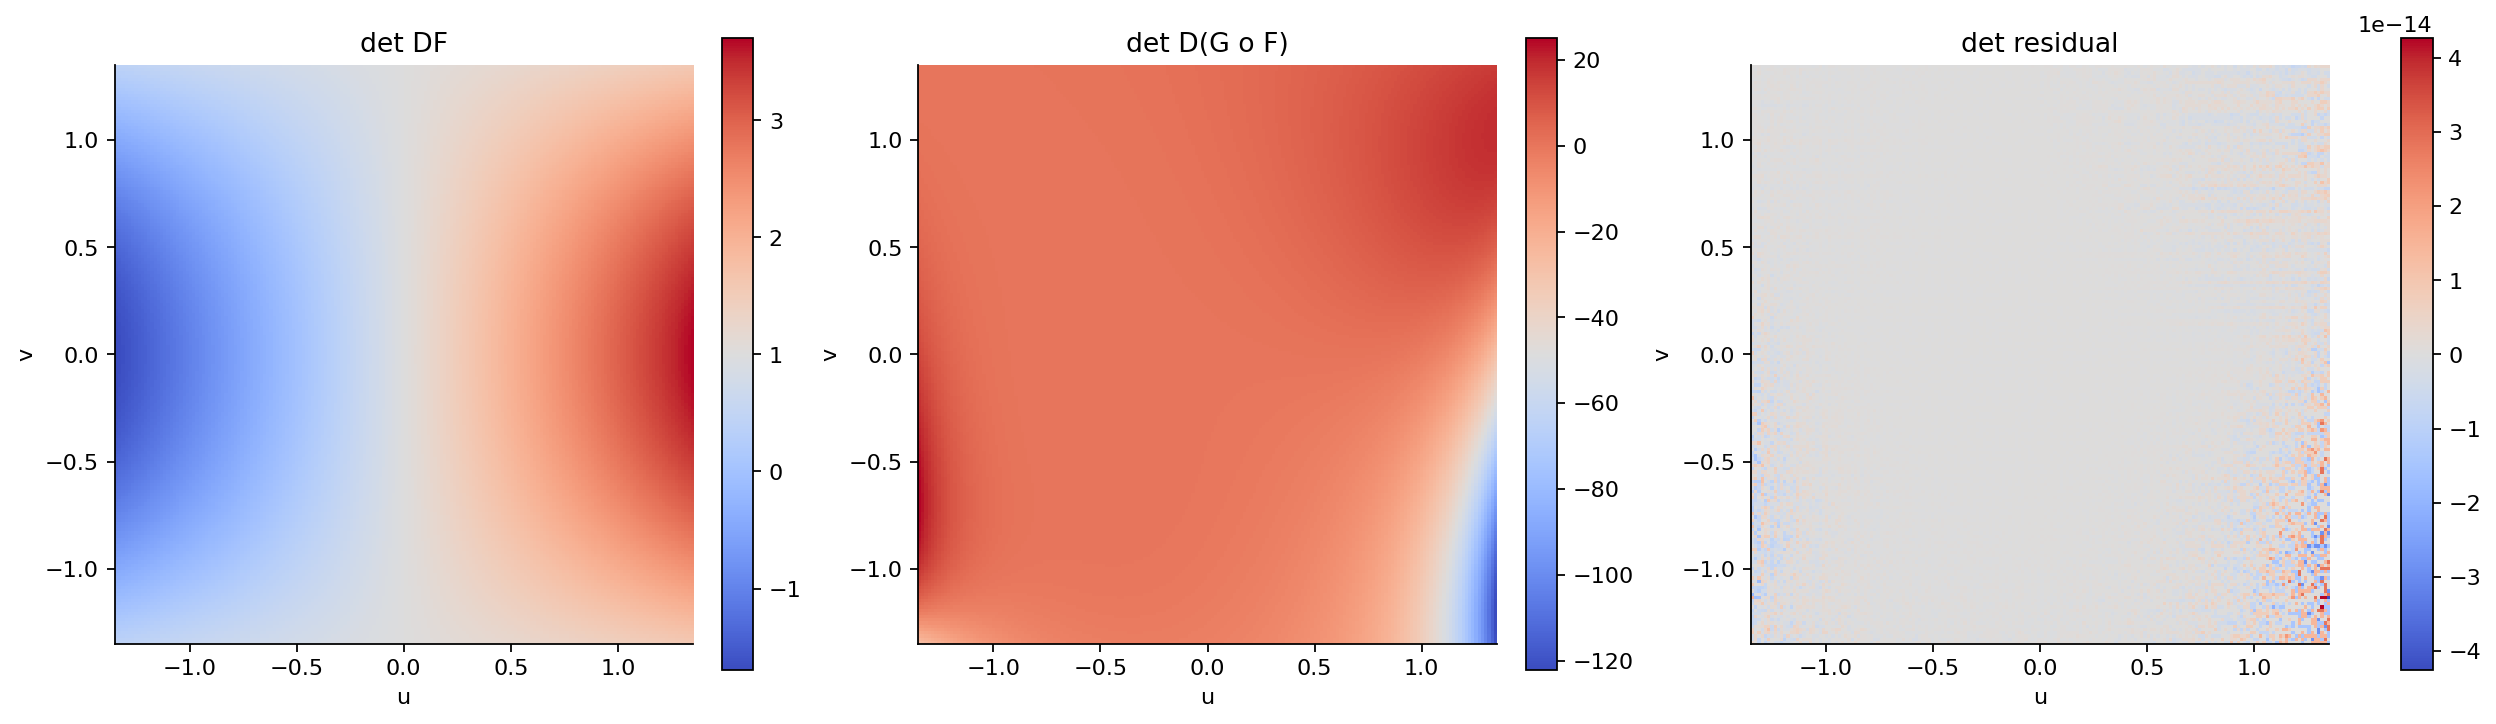

D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


,u,v,det_DF,det_DG_at_F_times_det_DF,det_D_composite,det_residual
0,-1.00,-0.5,-0.755165,1.770963,1.770963,0.000000e+00
1,-0.25,0.4,0.539470,0.150889,0.150889,-5.551115e-17
2,0.70,-0.9,1.870254,-10.411245,-10.411245,-1.776357e-15
3,1.10,1.0,2.188665,15.932490,15.932490,-3.552714e-15


In [4]:
u, v = sp.symbols("u v", real=True)
p, q = sp.symbols("p q", real=True)
F_expr = sp.Matrix([u**2 - v, u + sp.sin(v)])
G_expr = sp.Matrix([p * q, sp.exp(p) + q**2])
JF = F_expr.jacobian([u, v])
JG = G_expr.jacobian([p, q])
composite_expr = G_expr.subs({p: F_expr[0], q: F_expr[1]})
J_composite = composite_expr.jacobian([u, v])
chain_residual = sp.simplify(J_composite - JG.subs({p: F_expr[0], q: F_expr[1]}) * JF)
det_JF_expr = sp.simplify(JF.det())
det_comp_expr = sp.simplify(J_composite.det())
det_product_expr = sp.simplify(JG.det().subs({p: F_expr[0], q: F_expr[1]}) * det_JF_expr)
det_residual = sp.simplify(det_comp_expr - det_product_expr)

det_JF = sp.lambdify((u, v), det_JF_expr, "numpy")
det_comp = sp.lambdify((u, v), det_comp_expr, "numpy")
det_product = sp.lambdify((u, v), det_product_expr, "numpy")

uv_grid = np.linspace(-1.35, 1.35, 180)
U, V = np.meshgrid(uv_grid, uv_grid)
Z1 = det_JF(U, V)
Z2 = det_comp(U, V)
Z3 = det_comp(U, V) - det_product(U, V)

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.9), constrained_layout=True)
for ax, Z, title in [
    (axes[0], Z1, "det DF"),
    (axes[1], Z2, "det D(G o F)"),
    (axes[2], Z3, "det residual"),
]:
    im = ax.imshow(Z, extent=[uv_grid.min(), uv_grid.max(), uv_grid.min(), uv_grid.max()], origin="lower", cmap="coolwarm")
    ax.set_title(title)
    ax.set_xlabel("u")
    ax.set_ylabel("v")
    fig.colorbar(im, ax=ax, shrink=0.82)

jacobian_heatmap_path = record_artifact(save_matplotlib(fig, FIGURES / "jacobian-chain-rule-heatmaps.png"))
plt.close(fig)

fig_html = go.Figure()
fig_html.add_trace(go.Heatmap(x=uv_grid, y=uv_grid, z=Z1, colorscale="RdBu", zmid=0, colorbar=dict(title="det DF")))
fig_html.update_layout(title="Jacobian determinant of F(u,v)", xaxis_title="u", yaxis_title="v", width=780, height=620)
jacobian_html_path = record_artifact(save_plotly_html(fig_html, HTML / "jacobian-chain-rule-heatmaps.html"))

sample_points = [(-1.0, -0.5), (-0.25, 0.4), (0.7, -0.9), (1.1, 1.0)]
chain_rows = []
for uu, vv in sample_points:
    chain_rows.append({
        "u": uu,
        "v": vv,
        "det_DF": float(det_JF(uu, vv)),
        "det_DG_at_F_times_det_DF": float(det_product(uu, vv)),
        "det_D_composite": float(det_comp(uu, vv)),
        "det_residual": float(det_comp(uu, vv) - det_product(uu, vv)),
    })
chain_table_path = record_artifact(save_csv(chain_rows, TABLES / "jacobian-chain-rule-samples.csv"))
chain_checks = {
    "chain_rule_matrix_residual": str(chain_residual),
    "determinant_residual": str(det_residual),
    "max_numeric_det_residual": float(np.max(np.abs(Z3))),
    "sample_rows": chain_rows,
}
chain_checks_path = record_check(save_json(chain_checks, CHECKS / "jacobian-chain-rule-symbolic.json"))
assert chain_residual == sp.zeros(2)
assert det_residual == 0
assert chain_checks["max_numeric_det_residual"] < 1e-9
coverage["partial derivatives, Jacobian, smoothness"] = True
coverage["chain rule"] = True
display_artifact(jacobian_heatmap_path, width=980)
display_artifact(jacobian_html_path, width=820, height=620)
display(pd.DataFrame(chain_rows))

## 3. Mixed Partials And Directional Derivatives

The equality of mixed second partial derivatives is a `C^2` theorem. The smooth example below makes the common mixed field visible. The JSON check also records a standard warning: there are functions with both mixed partials at a point but without the needed continuity, and the two values can differ.

Directional derivatives are simpler once the total derivative is known. For scalar `f`, the directional derivative in direction `v` is `Df(a)v`, which is the dot product of the Euclidean gradient with `v`.

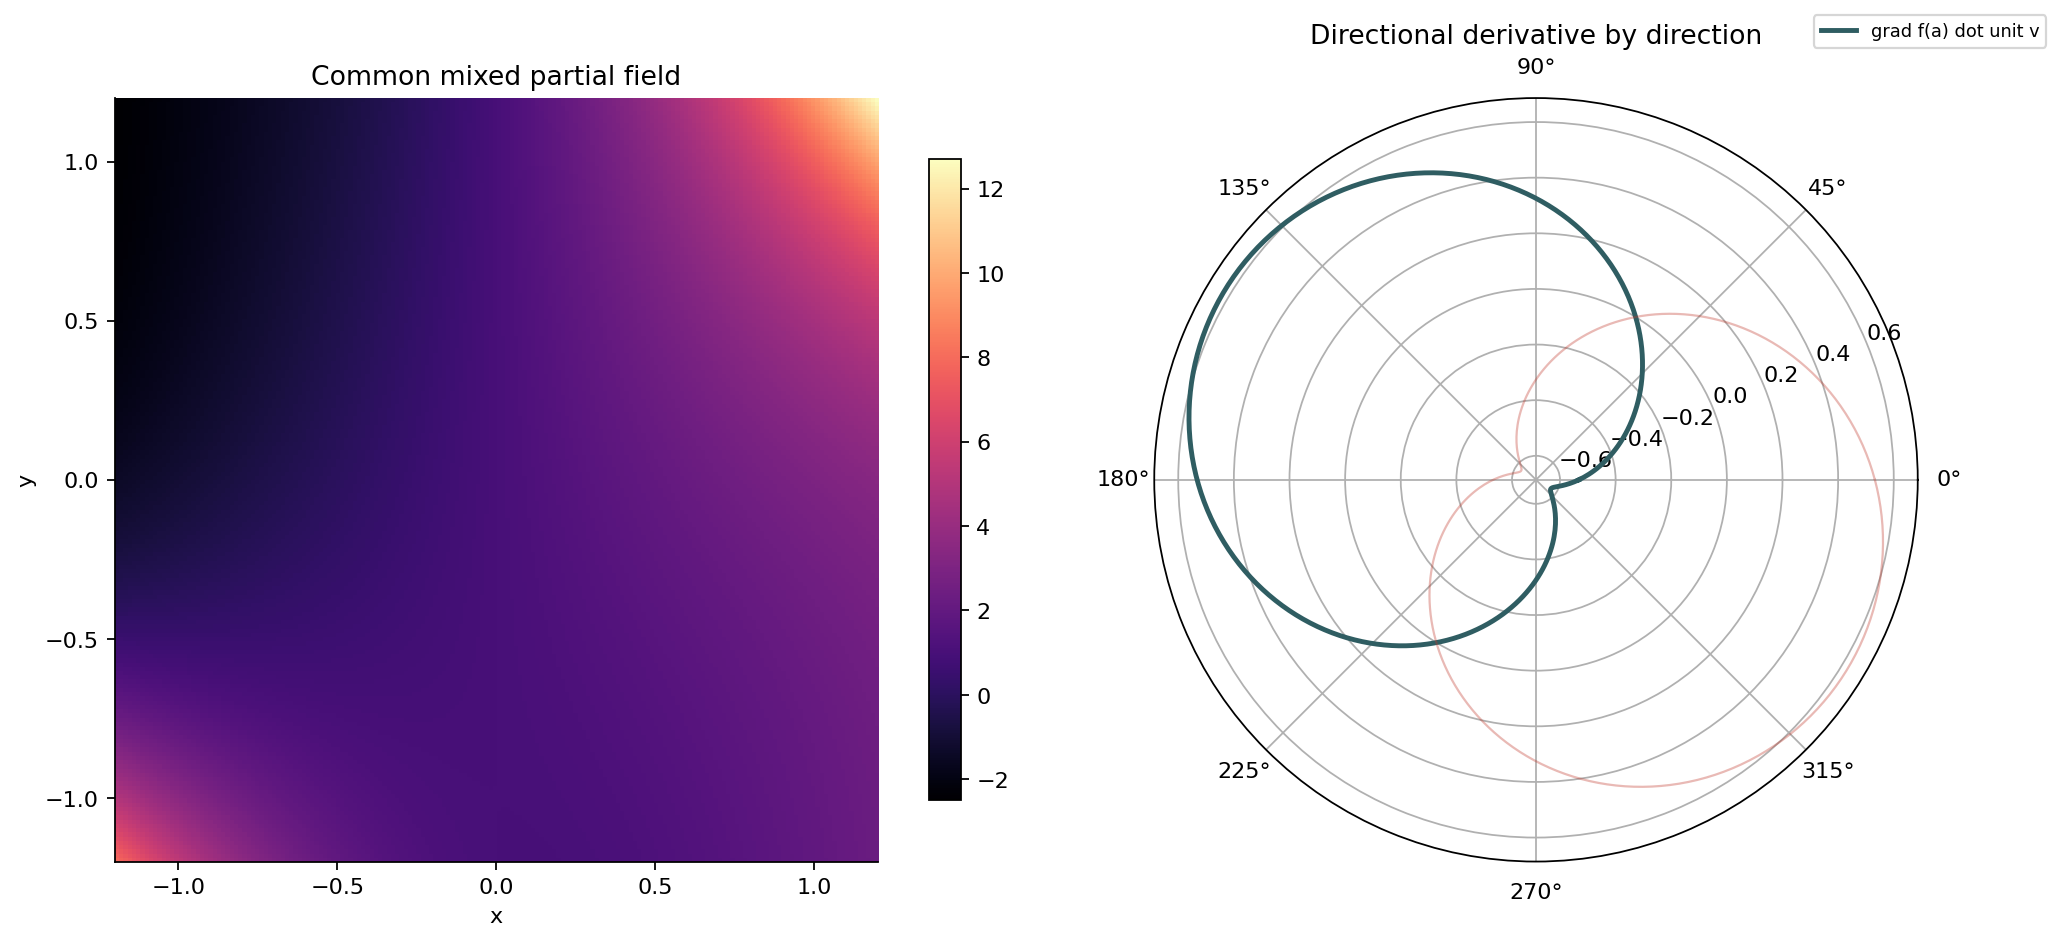

,length,max_abs_directional_derivative
0,0.5,0.311932
1,1.0,0.623863
2,1.5,0.935795


In [5]:
smooth_expr = sp.exp(x * y) + x**2 * y - y**3
mixed_xy = sp.diff(smooth_expr, x, y)
mixed_yx = sp.diff(smooth_expr, y, x)
mixed_residual = sp.simplify(mixed_xy - mixed_yx)
mixed_fun = sp.lambdify((x, y), mixed_xy, "numpy")
grad_smooth = [sp.lambdify((x, y), sp.diff(smooth_expr, var), "numpy") for var in (x, y)]

grid2 = np.linspace(-1.2, 1.2, 180)
X2, Y2 = np.meshgrid(grid2, grid2)
MIX = mixed_fun(X2, Y2)

a_direction = np.array([0.45, -0.3])
grad_at_a = np.array([float(g(*a_direction)) for g in grad_smooth])
angles = np.linspace(0, 2 * np.pi, 240)
lengths = np.array([0.5, 1.0, 1.5])
direction_rows = []
for length in lengths:
    values = []
    for angle in angles:
        vec = length * np.array([math.cos(angle), math.sin(angle)])
        values.append(float(grad_at_a @ vec))
    direction_rows.append({"length": float(length), "max_abs_directional_derivative": float(np.max(np.abs(values)))})

polar_values = np.array([grad_at_a @ np.array([math.cos(angle), math.sin(angle)]) for angle in angles])

fig = plt.figure(figsize=(14.0, 5.8), constrained_layout=True)
ax1 = fig.add_subplot(1, 2, 1)
im = ax1.imshow(MIX, extent=[grid2.min(), grid2.max(), grid2.min(), grid2.max()], origin="lower", cmap="magma")
ax1.set_title("Common mixed partial field")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
fig.colorbar(im, ax=ax1, shrink=0.84)

ax2 = fig.add_subplot(1, 2, 2, projection="polar")
ax2.plot(angles, polar_values, color="#2f5d62", lw=2.2, label="grad f(a) dot unit v")
ax2.plot(angles, -polar_values, color="#c0392b", lw=1.0, alpha=0.35)
ax2.set_title("Directional derivative by direction")
ax2.legend(loc="upper right", bbox_to_anchor=(1.18, 1.12), fontsize=8)

mixed_path = record_artifact(save_matplotlib(fig, FIGURES / "mixed-partials-directional-derivatives.png"))
plt.close(fig)

direction_table_path = record_artifact(save_csv(direction_rows, TABLES / "directional-derivative-scan.csv"))
non_c2_warning = {
    "example": "h(x,y)=x*y*(x^2-y^2)/(x^2+y^2), h(0,0)=0",
    "h_xy_at_origin": -1,
    "h_yx_at_origin": 1,
    "lesson": "existence of both mixed partials at one point is weaker than the C2 hypothesis",
}
mixed_checks = {
    "smooth_mixed_partial_residual": str(mixed_residual),
    "gradient_at_direction_base": grad_at_a.tolist(),
    "unit_direction_max_abs": float(np.max(np.abs(polar_values))),
    "unit_direction_expected_norm": float(np.linalg.norm(grad_at_a)),
    "non_c2_warning": non_c2_warning,
}
mixed_checks_path = record_check(save_json(mixed_checks, CHECKS / "mixed-partials-directional-checks.json"))
assert mixed_residual == 0
assert abs(mixed_checks["unit_direction_max_abs"] - mixed_checks["unit_direction_expected_norm"]) < 2e-4
coverage["mixed partials"] = True
coverage["directional derivatives"] = True
display_artifact(mixed_path, width=980)
display(pd.DataFrame(direction_rows))

## 4. Differentiating Under An Integral Sign And Taylor Remainders

Differentiation under an integral sign is a controlled interchange theorem: continuous partial derivatives in the parameter allow the derivative to move inside the integral. Taylor's theorem is another control statement: after subtracting the polynomial of degree `k`, the remainder is governed by derivatives of order `k+1`.

The exact SymPy check handles the interchange. The plot tests a second-order Taylor polynomial along a ray and compares the true error with a sampled cubic bound.

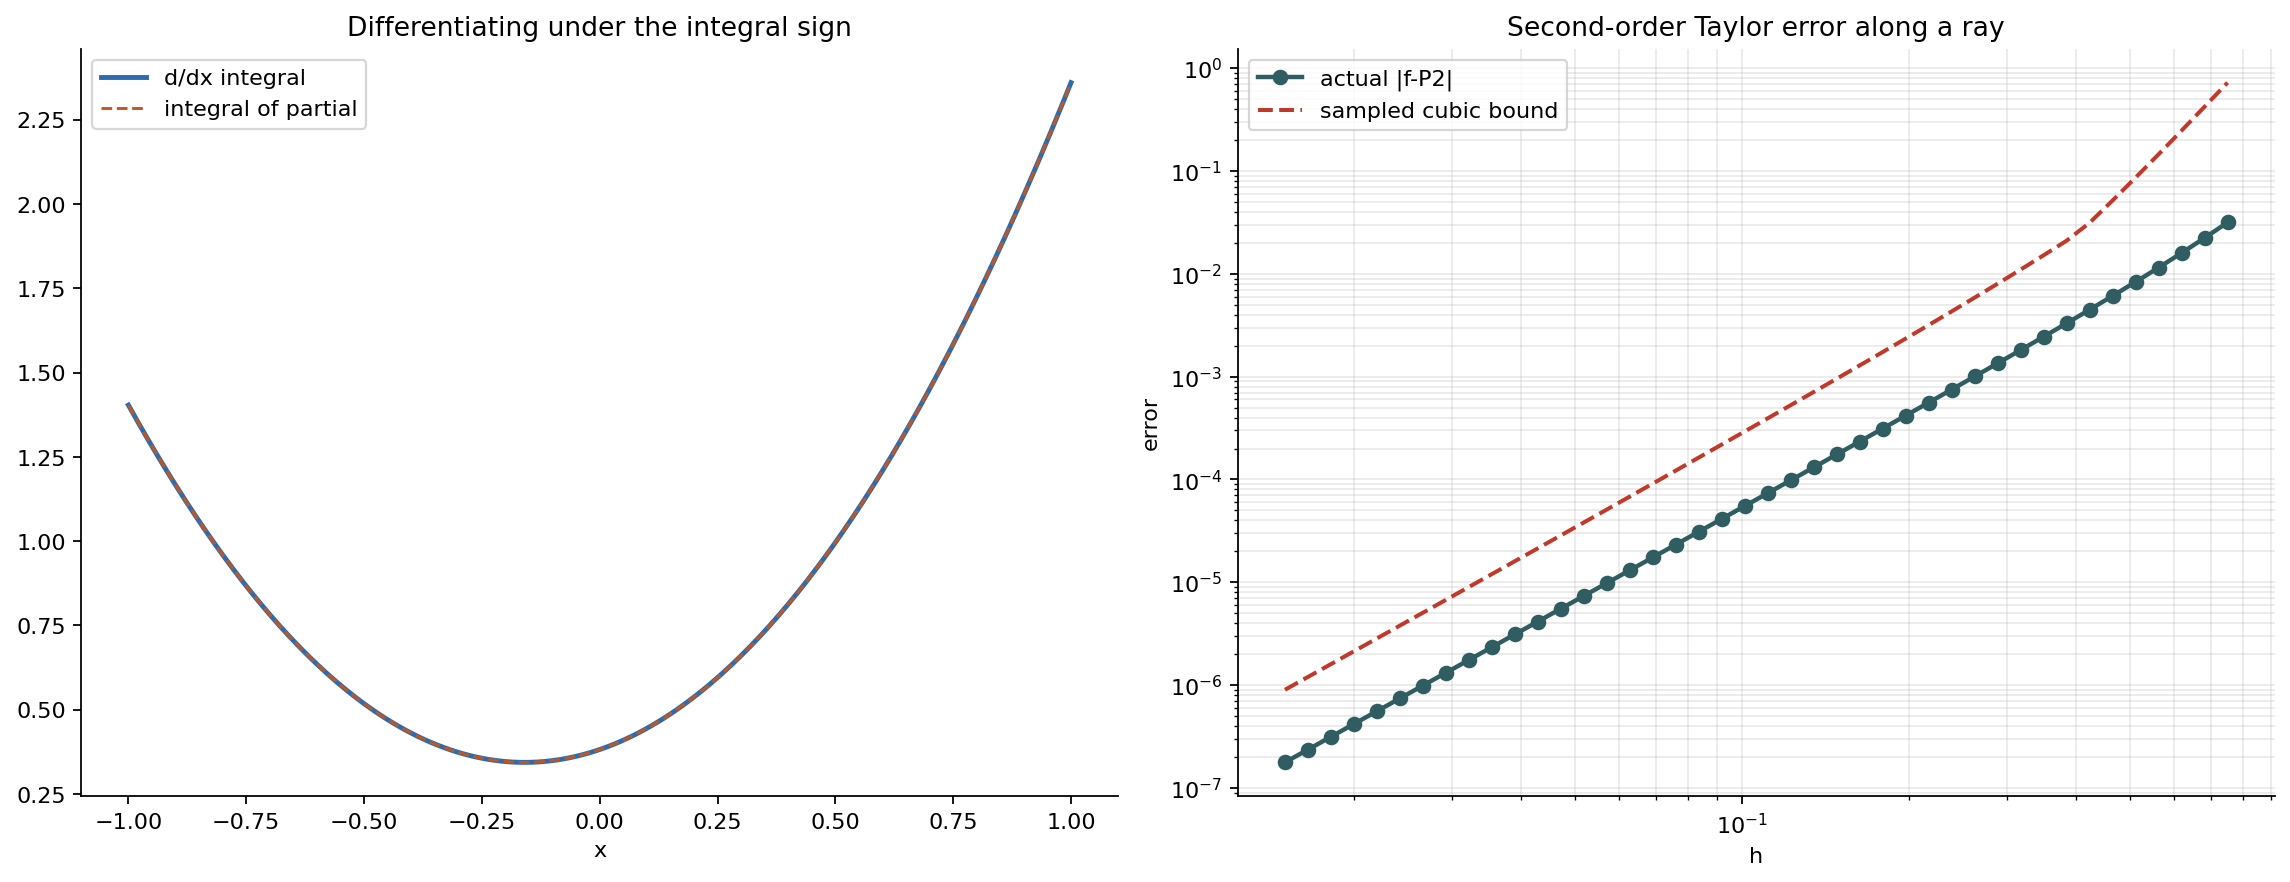

,h,abs_error,sampled_cubic_bound,error_over_h_cubed
0,0.015000,1.773203e-07,9.012872e-07,0.052539
1,0.016502,2.361483e-07,1.201220e-06,0.052553
2,0.018154,3.145012e-07,1.601129e-06,0.052568
3,0.019971,4.188632e-07,2.134417e-06,0.052584
4,0.021971,5.578737e-07,2.845684e-06,0.052602


In [6]:
t = sp.symbols("t", real=True)
parameter_integrand = (1 + x * t + x**2 * t**2) * sp.cos(t) + x**3 * t
F_integral = sp.integrate(parameter_integrand, (t, 0, 1))
d_integral = sp.diff(F_integral, x)
integral_d = sp.integrate(sp.diff(parameter_integrand, x), (t, 0, 1))
integral_residual = sp.simplify(d_integral - integral_d)

taylor_expr = sp.exp(sp.Rational(1, 2) * x - sp.Rational(3, 10) * y) + sp.sin(x * y)
P2 = 0
for i in range(3):
    for j in range(3 - i):
        coeff = sp.diff(taylor_expr, x, i, y, j).subs({x: 0, y: 0}) / (math.factorial(i) * math.factorial(j))
        P2 += coeff * x**i * y**j
P2 = sp.simplify(P2)
third_partials = [sp.diff(taylor_expr, x, i, y, 3 - i) for i in range(4)]
taylor_fun = sp.lambdify((x, y), taylor_expr, "numpy")
P2_fun = sp.lambdify((x, y), P2, "numpy")
third_funs = [sp.lambdify((x, y), expr, "numpy") for expr in third_partials]

ray = np.array([1.0, -0.6])
h_values = np.geomspace(0.015, 0.75, 42)
errors = []
bounds = []
for h in h_values:
    px, py = h * ray
    actual_error = abs(float(taylor_fun(px, py) - P2_fun(px, py)))
    sample_s = np.linspace(0, 1, 80)
    xs = sample_s * px
    ys = sample_s * py
    M = max(float(np.max(np.abs(third(xs, ys)))) for third in third_funs)
    bound = (2**3) * M * (float(np.linalg.norm([px, py])) ** 3) / math.factorial(3)
    errors.append(actual_error)
    bounds.append(bound)

fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.4), constrained_layout=True)
xx = np.linspace(-1.0, 1.0, 300)
d_integral_fun = sp.lambdify(x, d_integral, "numpy")
integral_d_fun = sp.lambdify(x, integral_d, "numpy")
axes[0].plot(xx, d_integral_fun(xx), color="#2b6cb0", lw=2.2, label="d/dx integral")
axes[0].plot(xx, integral_d_fun(xx), color="#c05621", lw=1.3, ls="--", label="integral of partial")
axes[0].set_title("Differentiating under the integral sign")
axes[0].set_xlabel("x")
axes[0].legend()

axes[1].loglog(h_values, errors, marker="o", color="#2f5d62", lw=2, label="actual |f-P2|")
axes[1].loglog(h_values, bounds, color="#c0392b", lw=1.8, ls="--", label="sampled cubic bound")
axes[1].set_title("Second-order Taylor error along a ray")
axes[1].set_xlabel("h")
axes[1].set_ylabel("error")
axes[1].grid(True, which="both", alpha=0.26)
axes[1].legend()

integral_taylor_path = record_artifact(save_matplotlib(fig, FIGURES / "differentiation-under-integral-and-taylor.png"))
plt.close(fig)

taylor_rows = [{"h": float(h), "abs_error": float(e), "sampled_cubic_bound": float(b), "error_over_h_cubed": float(e / h**3)} for h, e, b in zip(h_values, errors, bounds)]
taylor_table_path = record_artifact(save_csv(taylor_rows, TABLES / "taylor-remainder-errors.csv"))
integral_taylor_checks = {
    "integral_interchange_residual": str(integral_residual),
    "taylor_polynomial_order_2": str(P2),
    "max_error_minus_bound": float(np.max(np.array(errors) - np.array(bounds))),
    "small_h_error_over_h_cubed": float(taylor_rows[0]["error_over_h_cubed"]),
}
integral_taylor_checks_path = record_check(save_json(integral_taylor_checks, CHECKS / "integral-and-taylor-checks.json"))
assert integral_residual == 0
assert integral_taylor_checks["max_error_minus_bound"] <= 1e-10
coverage["differentiation under integral sign"] = True
coverage["Taylor theorem with remainder"] = True
display_artifact(integral_taylor_path, width=980)
display(pd.DataFrame(taylor_rows).head())

## 5. Riemann Integration, Domains, Boundary, And Volume

Appendix C uses Riemann integration because it is enough for the smooth and piecewise smooth domains later in the book. The lower and upper sums squeeze the integral over a rectangle. For more general bounded sets, a domain of integration has boundary of measure zero, so extending a bounded continuous function by zero only creates discontinuities on a negligible set.

The disk panel approximates the boundary by a thin annulus. As the tube width shrinks, its area shrinks too; this is the computational shadow of a measure-zero boundary.

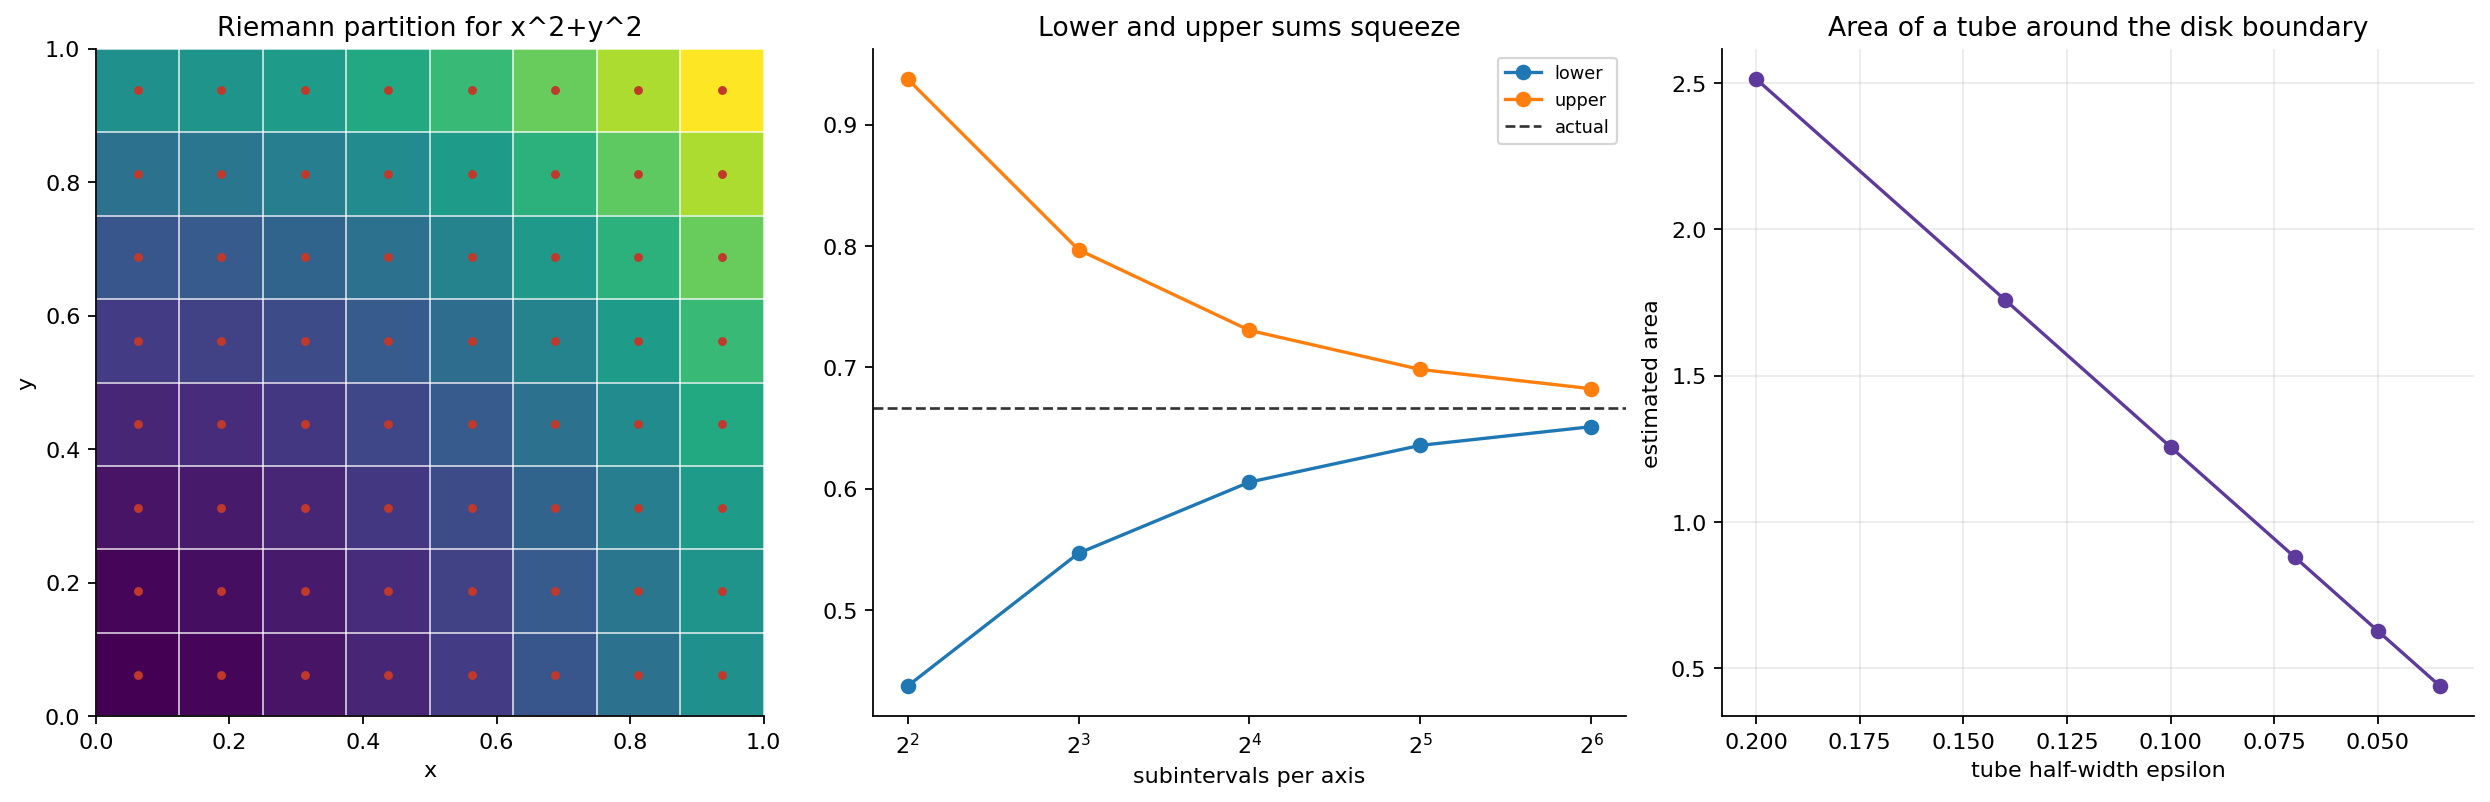

,n,lower_sum,upper_sum,gap,actual_integral
0,4,0.437500,0.937500,0.50000,0.666667
1,8,0.546875,0.796875,0.25000,0.666667
2,16,0.605469,0.730469,0.12500,0.666667
3,32,0.635742,0.698242,0.06250,0.666667
4,64,0.651123,0.682373,0.03125,0.666667


In [7]:
def lower_upper_sum_for_quadratic(n: int) -> tuple[float, float]:
    xs = np.linspace(0, 1, n + 1)
    ys = np.linspace(0, 1, n + 1)
    lower = 0.0
    upper = 0.0
    area = (1 / n) ** 2
    for i in range(n):
        for j in range(n):
            lower += (xs[i] ** 2 + ys[j] ** 2) * area
            upper += (xs[i + 1] ** 2 + ys[j + 1] ** 2) * area
    return lower, upper


partition_ns = [4, 8, 16, 32, 64]
actual_integral = 2 / 3
partition_rows = []
for n in partition_ns:
    lower, upper = lower_upper_sum_for_quadratic(n)
    partition_rows.append({"n": n, "lower_sum": lower, "upper_sum": upper, "gap": upper - lower, "actual_integral": actual_integral})

N_show = 8
cells = np.linspace(0, 1, N_show + 1)
centers = (cells[:-1] + cells[1:]) / 2
CX, CY = np.meshgrid(centers, centers)
ZC = CX**2 + CY**2

eps_values = np.array([0.20, 0.14, 0.10, 0.07, 0.05, 0.035])
grid_domain = np.linspace(-1.25, 1.25, 900)
DX, DY = np.meshgrid(grid_domain, grid_domain)
R = np.sqrt(DX**2 + DY**2)
cell_area = (grid_domain[1] - grid_domain[0]) ** 2
boundary_rows = []
for eps in eps_values:
    tube_area = float(np.sum(np.abs(R - 1.0) <= eps) * cell_area)
    boundary_rows.append({"epsilon": float(eps), "estimated_boundary_tube_area": tube_area})
disk_area_estimate = float(np.sum(R <= 1.0) * cell_area)

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.9), constrained_layout=True)
axes[0].imshow(ZC, origin="lower", extent=[0, 1, 0, 1], cmap="viridis")
for c in cells:
    axes[0].plot([c, c], [0, 1], color="white", lw=0.8, alpha=0.75)
    axes[0].plot([0, 1], [c, c], color="white", lw=0.8, alpha=0.75)
axes[0].scatter(CX.ravel(), CY.ravel(), s=9, color="#c0392b", label="sample points")
axes[0].set_title("Riemann partition for x^2+y^2")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

axes[1].plot([row["n"] for row in partition_rows], [row["lower_sum"] for row in partition_rows], marker="o", label="lower")
axes[1].plot([row["n"] for row in partition_rows], [row["upper_sum"] for row in partition_rows], marker="o", label="upper")
axes[1].axhline(actual_integral, color="#333333", lw=1.2, ls="--", label="actual")
axes[1].set_xscale("log", base=2)
axes[1].set_title("Lower and upper sums squeeze")
axes[1].set_xlabel("subintervals per axis")
axes[1].legend(fontsize=8)

axes[2].plot(eps_values, [row["estimated_boundary_tube_area"] for row in boundary_rows], marker="o", color="#5d3a9b")
axes[2].invert_xaxis()
axes[2].set_title("Area of a tube around the disk boundary")
axes[2].set_xlabel("tube half-width epsilon")
axes[2].set_ylabel("estimated area")
axes[2].grid(True, alpha=0.25)

riemann_path = record_artifact(save_matplotlib(fig, FIGURES / "riemann-partitions-domain-boundary.png"))
plt.close(fig)
partition_table_path = record_artifact(save_csv(partition_rows, TABLES / "riemann-partition-sums.csv"))
boundary_table_path = record_artifact(save_csv(boundary_rows, TABLES / "boundary-tube-area.csv"))
riemann_checks = {
    "actual_integral_x2_plus_y2_unit_square": actual_integral,
    "gap_first": float(partition_rows[0]["gap"]),
    "gap_last": float(partition_rows[-1]["gap"]),
    "gap_decreases": bool(partition_rows[-1]["gap"] < 0.08 * partition_rows[0]["gap"]),
    "disk_area_estimate": disk_area_estimate,
    "pi_error": float(abs(disk_area_estimate - math.pi)),
    "smallest_boundary_tube_area": float(boundary_rows[-1]["estimated_boundary_tube_area"]),
}
riemann_checks_path = record_check(save_json(riemann_checks, CHECKS / "riemann-domain-volume-checks.json"))
assert riemann_checks["gap_decreases"]
assert riemann_checks["pi_error"] < 0.02
coverage["Riemann integration and domains"] = True
display_artifact(riemann_path, width=980)
display(pd.DataFrame(partition_rows))

## 6. Change Of Variables: Determinants As Area Scale

For a diffeomorphism `G` between domains in `R^n`, integrals transform by multiplying the pulled-back integrand by `abs(det DG)`. In polar coordinates, the map `(r, theta) -> (r cos theta, r sin theta)` has Jacobian determinant `r`. The determinant is not decoration; it is the limit of image-cell area divided by parameter-cell area.

The static figure shows the annular sector and determinant scale. The HTML artifact gives the same grid in an inspectable form.

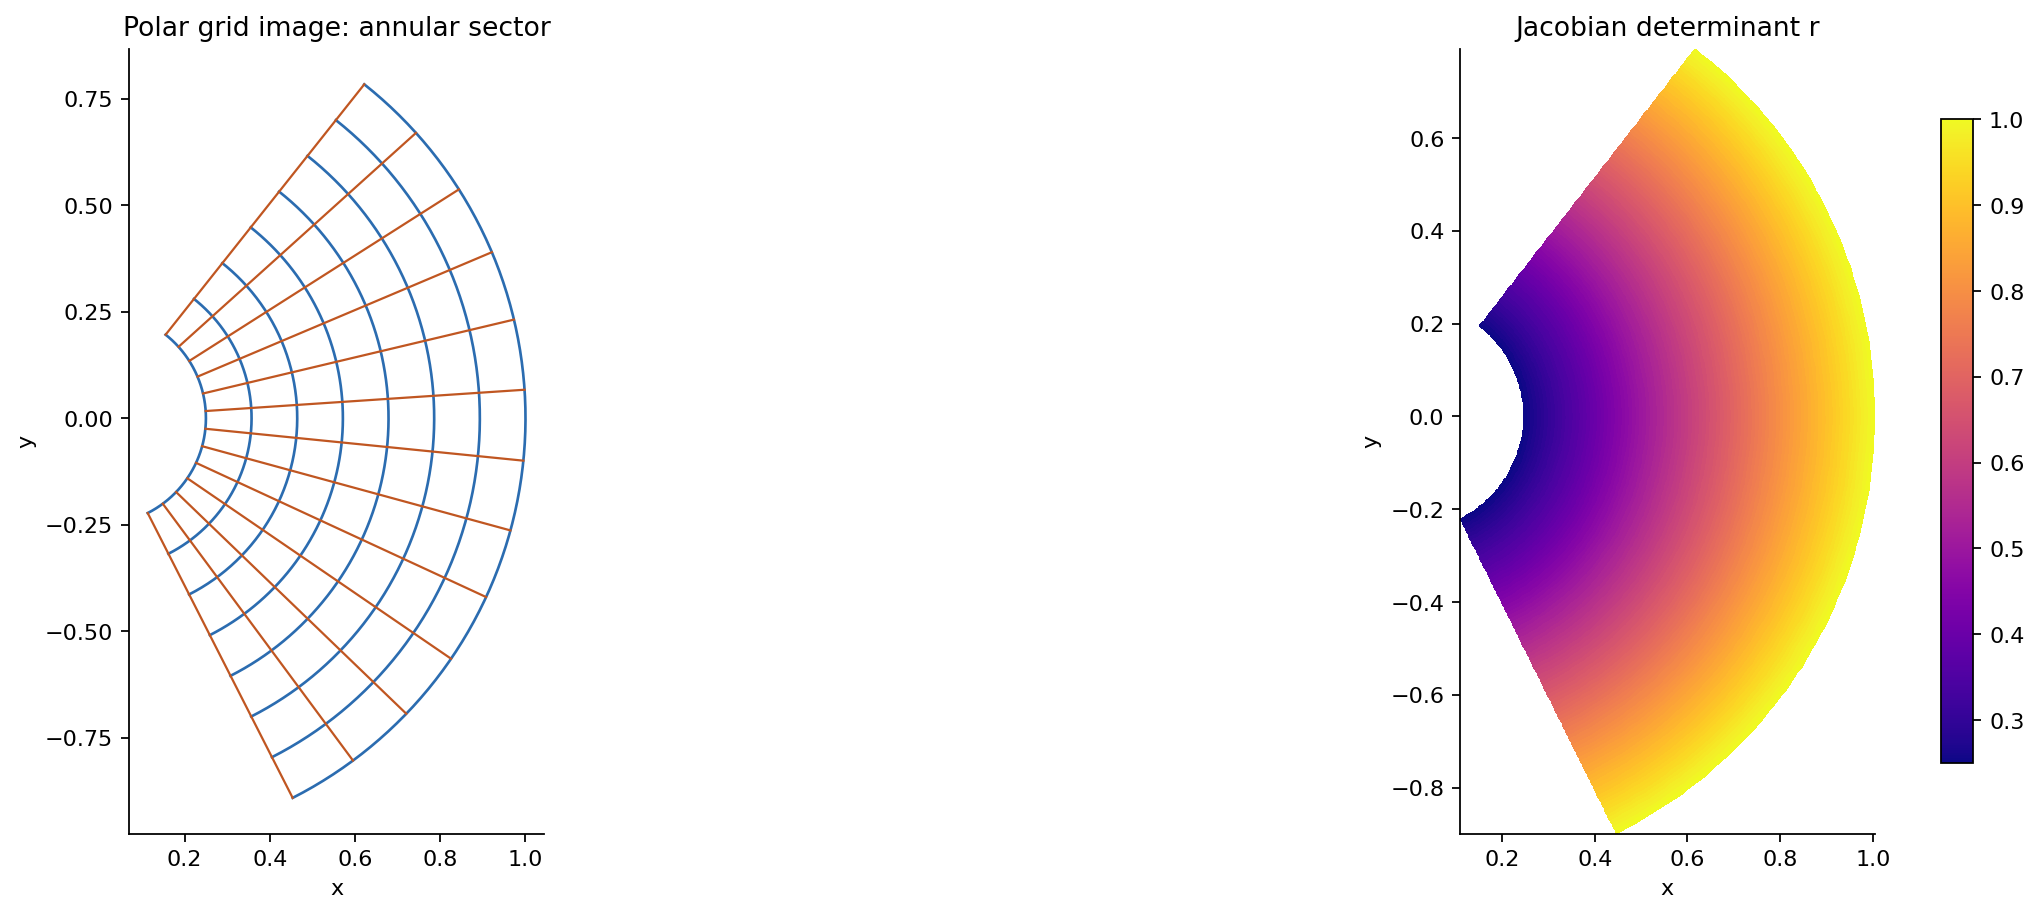

D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


In [8]:
r_min, r_max = 0.25, 1.0
theta_min, theta_max = -1.1, 0.9
r_lines = np.linspace(r_min, r_max, 8)
theta_lines = np.linspace(theta_min, theta_max, 13)

def polar_map(rr, th):
    return rr * np.cos(th), rr * np.sin(th)


fig, axes = plt.subplots(1, 2, figsize=(13.8, 5.6), constrained_layout=True)
for rr in r_lines:
    ths = np.linspace(theta_min, theta_max, 220)
    xs, ys = polar_map(rr, ths)
    axes[0].plot(xs, ys, color="#2b6cb0", lw=1.2)
for th in theta_lines:
    rs = np.linspace(r_min, r_max, 160)
    xs, ys = polar_map(rs, th)
    axes[0].plot(xs, ys, color="#c05621", lw=1.0)
axes[0].set_aspect("equal")
axes[0].set_title("Polar grid image: annular sector")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

rr_grid = np.linspace(r_min, r_max, 100)
th_grid = np.linspace(theta_min, theta_max, 100)
RR, TT = np.meshgrid(rr_grid, th_grid)
XX, YY = polar_map(RR, TT)
distortion = RR
im = axes[1].pcolormesh(XX, YY, distortion, shading="auto", cmap="plasma")
axes[1].set_aspect("equal")
axes[1].set_title("Jacobian determinant r")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
fig.colorbar(im, ax=axes[1], shrink=0.82)

change_path = record_artifact(save_matplotlib(fig, FIGURES / "change-of-variables-area-distortion.png"))
plt.close(fig)

fig_html = go.Figure()
for rr in r_lines:
    ths = np.linspace(theta_min, theta_max, 220)
    xs, ys = polar_map(rr, ths)
    fig_html.add_trace(go.Scatter(x=xs, y=ys, mode="lines", line=dict(color="#2b6cb0", width=2), showlegend=False, hovertemplate=f"r={rr:0.3f}<extra></extra>"))
for th in theta_lines:
    rs = np.linspace(r_min, r_max, 160)
    xs, ys = polar_map(rs, th)
    fig_html.add_trace(go.Scatter(x=xs, y=ys, mode="lines", line=dict(color="#c05621", width=1.5), showlegend=False, hovertemplate=f"theta={th:0.3f}<extra></extra>"))
fig_html.update_layout(title="Polar change of variables grid", xaxis_title="x", yaxis_title="y", width=780, height=620, yaxis_scaleanchor="x")
change_html_path = record_artifact(save_plotly_html(fig_html, HTML / "change-of-variables-area-distortion.html"))

cell_rows = []
for i in range(len(r_lines) - 1):
    for j in range(len(theta_lines) - 1):
        corners = [
            polar_map(r_lines[i], theta_lines[j]),
            polar_map(r_lines[i + 1], theta_lines[j]),
            polar_map(r_lines[i + 1], theta_lines[j + 1]),
            polar_map(r_lines[i], theta_lines[j + 1]),
        ]
        poly = np.array(corners)
        shoelace = 0.5 * abs(np.dot(poly[:, 0], np.roll(poly[:, 1], -1)) - np.dot(poly[:, 1], np.roll(poly[:, 0], -1)))
        dr = r_lines[i + 1] - r_lines[i]
        dtheta = theta_lines[j + 1] - theta_lines[j]
        r_mid = 0.5 * (r_lines[i] + r_lines[i + 1])
        predicted = r_mid * dr * dtheta
        cell_rows.append({"r_mid": float(r_mid), "theta_mid": float(0.5 * (theta_lines[j] + theta_lines[j + 1])), "image_cell_area": float(shoelace), "jacobian_midpoint_area": float(predicted), "relative_error": float(abs(shoelace - predicted) / predicted)})
area_table_path = record_artifact(save_csv(cell_rows, TABLES / "polar-area-cell-distortion.csv"))
sector_area_formula = 0.5 * (r_max**2 - r_min**2) * (theta_max - theta_min)
sector_area_cells = float(sum(row["image_cell_area"] for row in cell_rows))
change_checks = {
    "determinant": "r",
    "sector_area_formula": sector_area_formula,
    "sector_area_from_cells": sector_area_cells,
    "max_midpoint_relative_cell_error": float(max(row["relative_error"] for row in cell_rows)),
}
change_checks_path = record_check(save_json(change_checks, CHECKS / "change-of-variables-area-distortion.json"))
assert change_checks["max_midpoint_relative_cell_error"] < 0.08
assert abs(sector_area_formula - sector_area_cells) < 0.03
coverage["change of variables"] = True
display_artifact(change_path, width=980)
display_artifact(change_html_path, width=820, height=620)

## 7. Vector-Valued Integrals And Estimates

Vector-valued integration is componentwise, but the most useful estimate is geometric:

`|int_D F dV| <= int_D |F| dV`.

Appendix C also uses this estimate to prove a local Lipschitz bound for a `C^1` map on a compact convex set. The derivative bound controls how far images of two points can separate.

C:\Users\rahul\AppData\Local\Temp\ipykernel_27984\2573747655.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_vector = np.trapz(curve_F, tt, axis=0)
C:\Users\rahul\AppData\Local\Temp\ipykernel_27984\2573747655.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_of_norm = float(np.trapz(np.linalg.norm(curve_F, axis=1), tt))


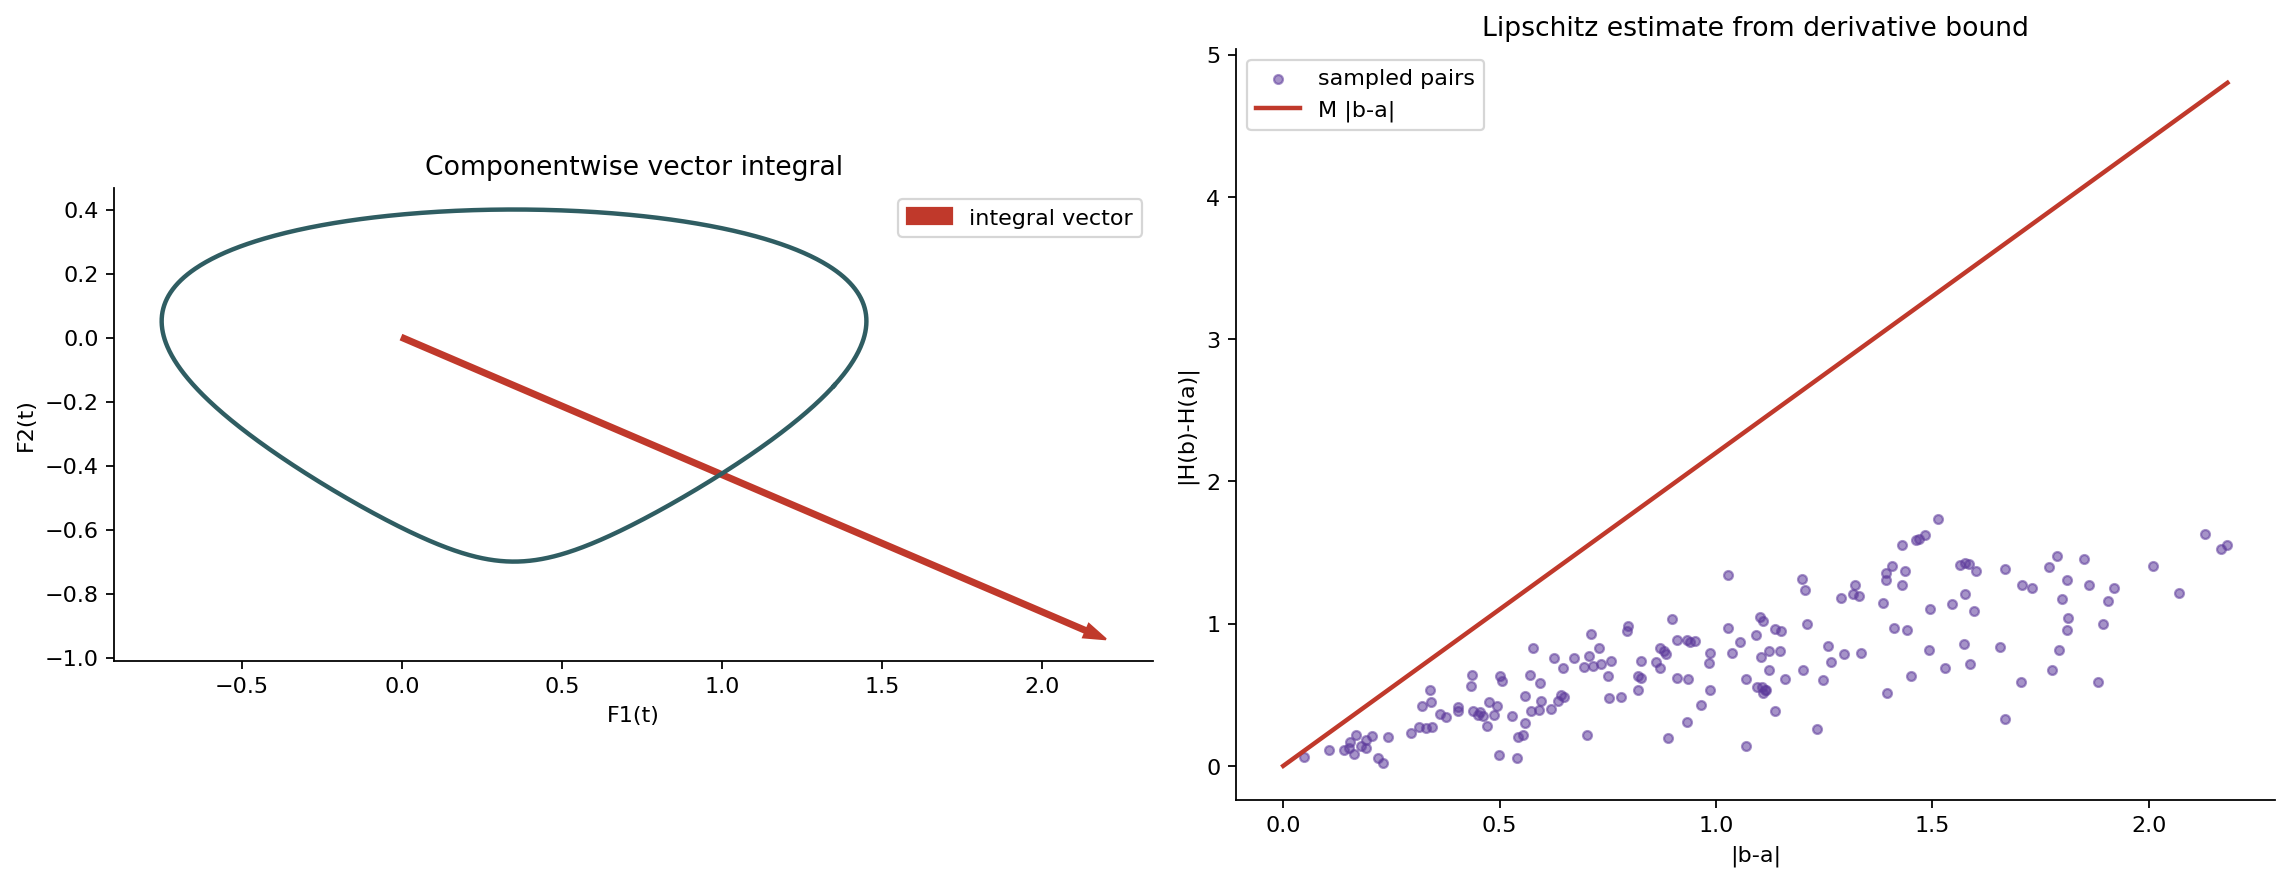

,quantity,value
0,norm_of_integral,2.392566
1,integral_of_norm,5.365380
2,sampled_derivative_frobenius_bound,2.200669
3,max_sampled_lipschitz_ratio,1.579122


In [9]:
tt = np.linspace(0, 2 * np.pi, 1200)
dt = tt[1] - tt[0]
curve_F = np.column_stack([0.35 + np.cos(tt) + 0.25 * np.sin(2 * tt), -0.15 + 0.55 * np.sin(tt)])
integral_vector = np.trapz(curve_F, tt, axis=0)
integral_norm = float(np.linalg.norm(integral_vector))
integral_of_norm = float(np.trapz(np.linalg.norm(curve_F, axis=1), tt))

def H_map(points: np.ndarray) -> np.ndarray:
    xx = points[:, 0]
    yy = points[:, 1]
    return np.column_stack([np.sin(xx) + 0.2 * yy**2, np.cos(yy) + xx * yy])


sample_axis = np.linspace(-1, 1, 141)
HX, HY = np.meshgrid(sample_axis, sample_axis)
frobenius = np.sqrt(np.cos(HX) ** 2 + (0.4 * HY) ** 2 + HY**2 + (-np.sin(HY) + HX) ** 2)
M_bound = float(np.max(frobenius))
rng = np.random.default_rng(42)
pairs_a = rng.uniform(-1, 1, size=(180, 2))
pairs_b = rng.uniform(-1, 1, size=(180, 2))
Ha = H_map(pairs_a)
Hb = H_map(pairs_b)
domain_dist = np.linalg.norm(pairs_b - pairs_a, axis=1)
image_dist = np.linalg.norm(Hb - Ha, axis=1)
ratios = image_dist / domain_dist

fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.4), constrained_layout=True)
axes[0].plot(curve_F[:, 0], curve_F[:, 1], color="#2f5d62", lw=2)
axes[0].arrow(0, 0, integral_vector[0], integral_vector[1], color="#c0392b", width=0.015, length_includes_head=True, label="integral vector")
axes[0].set_aspect("equal")
axes[0].set_title("Componentwise vector integral")
axes[0].set_xlabel("F1(t)")
axes[0].set_ylabel("F2(t)")
axes[0].legend()

axes[1].scatter(domain_dist, image_dist, s=16, alpha=0.55, color="#5d3a9b", label="sampled pairs")
line_x = np.linspace(0, domain_dist.max(), 80)
axes[1].plot(line_x, M_bound * line_x, color="#c0392b", lw=2, label="M |b-a|")
axes[1].set_title("Lipschitz estimate from derivative bound")
axes[1].set_xlabel("|b-a|")
axes[1].set_ylabel("|H(b)-H(a)|")
axes[1].legend()

vector_path = record_artifact(save_matplotlib(fig, FIGURES / "vector-integral-and-lipschitz-estimate.png"))
plt.close(fig)

vector_rows = [
    {"quantity": "norm_of_integral", "value": integral_norm},
    {"quantity": "integral_of_norm", "value": integral_of_norm},
    {"quantity": "sampled_derivative_frobenius_bound", "value": M_bound},
    {"quantity": "max_sampled_lipschitz_ratio", "value": float(np.max(ratios))},
]
vector_table_path = record_artifact(save_csv(vector_rows, TABLES / "vector-integral-estimate.csv"))
vector_checks = {
    "integral_vector": integral_vector.tolist(),
    "norm_of_integral": integral_norm,
    "integral_of_norm": integral_of_norm,
    "vector_integral_estimate_holds": bool(integral_norm <= integral_of_norm + 1e-10),
    "sampled_derivative_frobenius_bound": M_bound,
    "max_sampled_lipschitz_ratio": float(np.max(ratios)),
    "lipschitz_samples_below_bound": bool(np.max(ratios) <= M_bound + 1e-10),
}
vector_checks_path = record_check(save_json(vector_checks, CHECKS / "vector-integral-and-lipschitz-estimate.json"))
assert vector_checks["vector_integral_estimate_holds"]
assert vector_checks["lipschitz_samples_below_bound"]
coverage["vector-valued integrals and estimates"] = True
display_artifact(vector_path, width=980)
display(pd.DataFrame(vector_rows))

## 8. Uniform Convergence And Interchanging Limits

Uniform convergence gives a uniform error budget over the whole set, so integrals over compact domains can pass to the limit. Derivatives need a stronger hypothesis: the derivative sequence must converge uniformly, not merely the functions.

The "good" sequence below has both function and derivative errors tending uniformly to zero. The oscillatory sequence still converges uniformly as functions, but its derivatives keep oscillating with size about one.

C:\Users\rahul\AppData\Local\Temp\ipykernel_27984\449593835.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  good_integral_error = abs(np.trapz(xline**2 + np.sin(xline) / N, xline) - 1 / 3)
C:\Users\rahul\AppData\Local\Temp\ipykernel_27984\449593835.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  bad_integral_error = abs(np.trapz(xline**2 + np.sin(N * xline) / N, xline) - 1 / 3)


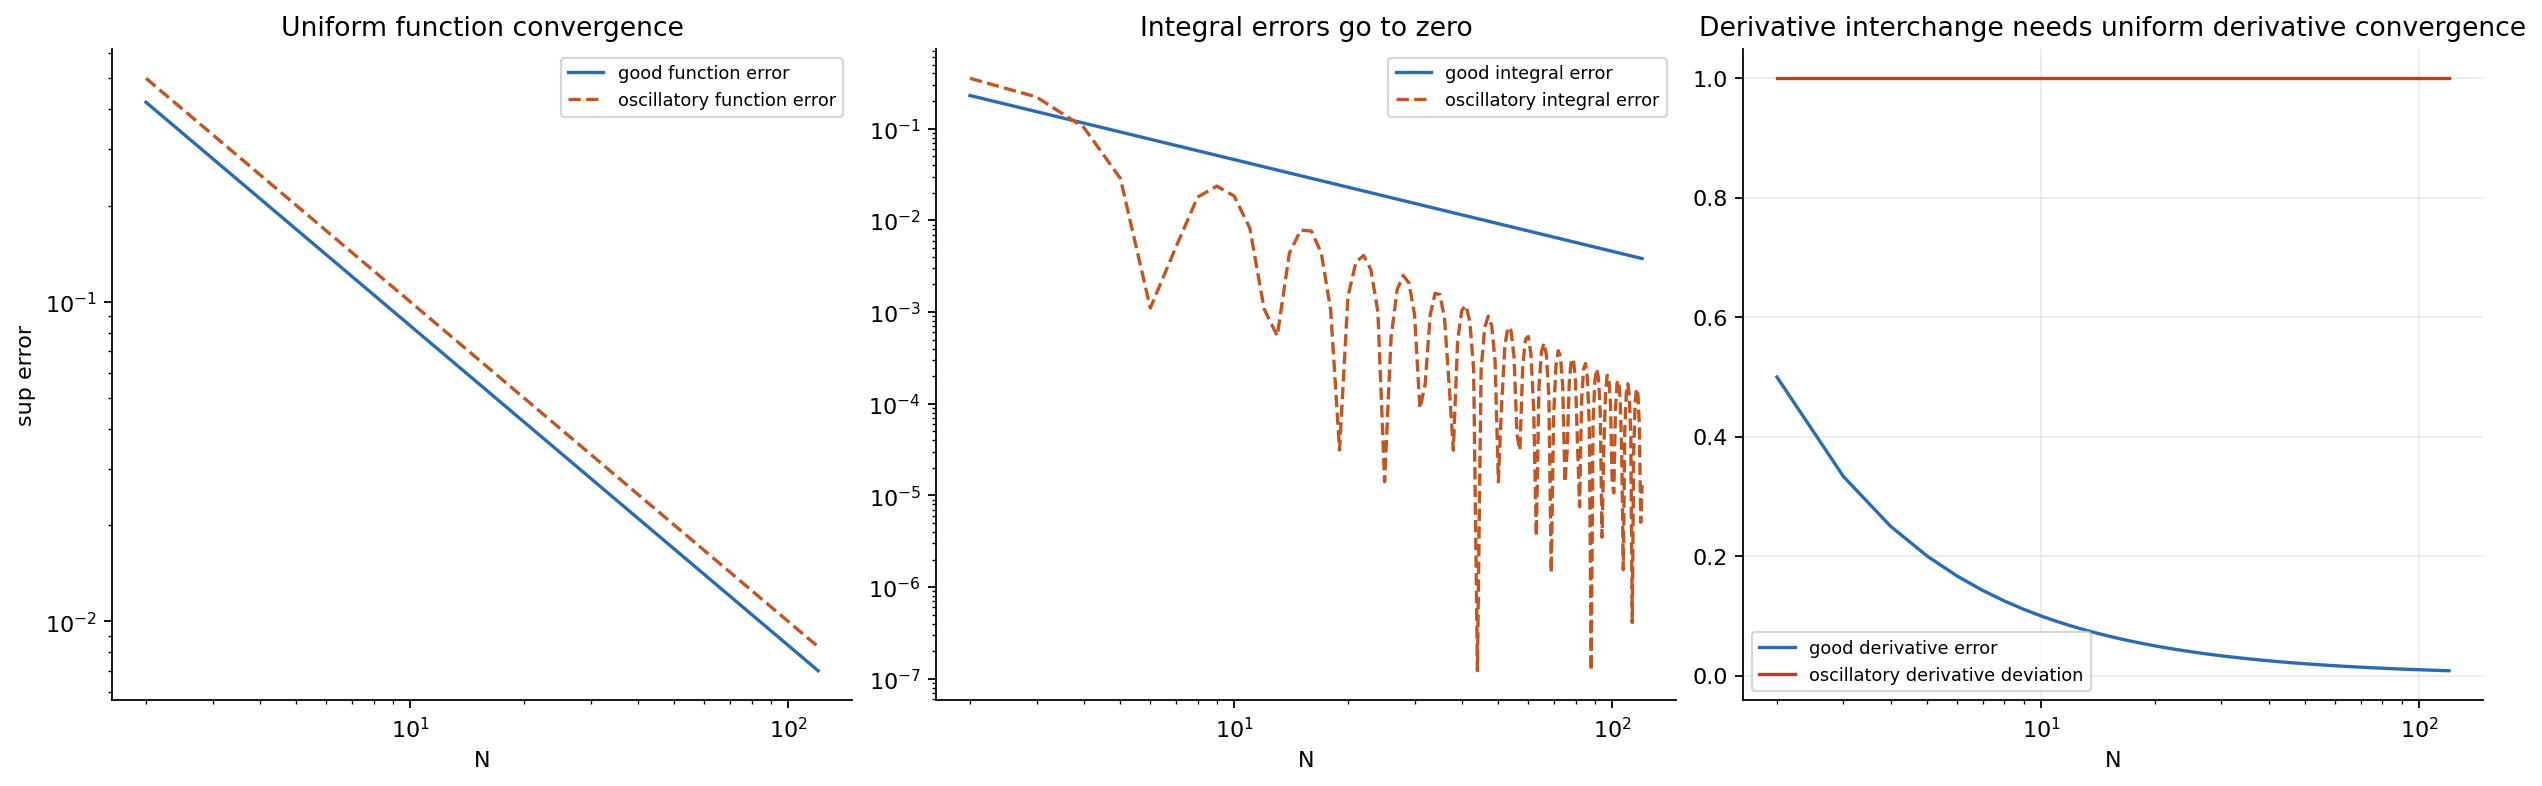

,N,function_sup_error,derivative_sup_error,integral_error
0,116,0.007254,0.008621,0.003963
1,117,0.007192,0.008547,0.003929
2,118,0.007131,0.008475,0.003896
3,119,0.007071,0.008403,0.003863
4,120,0.007012,0.008333,0.003831


In [10]:
Ns = np.arange(2, 121)
xline = np.linspace(0, 1, 2000)
good_rows = []
bad_rows = []
for N in Ns:
    good_error = np.max(np.abs(np.sin(xline) / N))
    good_deriv_error = np.max(np.abs(np.cos(xline) / N))
    good_integral_error = abs(np.trapz(xline**2 + np.sin(xline) / N, xline) - 1 / 3)

    bad_error = np.max(np.abs(np.sin(N * xline) / N))
    bad_deriv_deviation = np.max(np.abs(np.cos(N * xline)))
    bad_integral_error = abs(np.trapz(xline**2 + np.sin(N * xline) / N, xline) - 1 / 3)
    good_rows.append({"N": int(N), "function_sup_error": float(good_error), "derivative_sup_error": float(good_deriv_error), "integral_error": float(good_integral_error)})
    bad_rows.append({"N": int(N), "function_sup_error": float(bad_error), "derivative_deviation": float(bad_deriv_deviation), "integral_error": float(bad_integral_error)})

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.8), constrained_layout=True)
axes[0].loglog(Ns, [row["function_sup_error"] for row in good_rows], label="good function error", color="#2b6cb0")
axes[0].loglog(Ns, [row["function_sup_error"] for row in bad_rows], label="oscillatory function error", color="#c05621", ls="--")
axes[0].set_title("Uniform function convergence")
axes[0].set_xlabel("N")
axes[0].set_ylabel("sup error")
axes[0].legend(fontsize=8)

axes[1].loglog(Ns, [row["integral_error"] for row in good_rows], label="good integral error", color="#2b6cb0")
axes[1].loglog(Ns, [row["integral_error"] for row in bad_rows], label="oscillatory integral error", color="#c05621", ls="--")
axes[1].set_title("Integral errors go to zero")
axes[1].set_xlabel("N")
axes[1].legend(fontsize=8)

axes[2].semilogx(Ns, [row["derivative_sup_error"] for row in good_rows], label="good derivative error", color="#2b6cb0")
axes[2].semilogx(Ns, [row["derivative_deviation"] for row in bad_rows], label="oscillatory derivative deviation", color="#c0392b")
axes[2].set_title("Derivative interchange needs uniform derivative convergence")
axes[2].set_xlabel("N")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.25)

uniform_path = record_artifact(save_matplotlib(fig, FIGURES / "uniform-convergence-interchange.png"))
plt.close(fig)
uniform_table_path = record_artifact(save_csv(good_rows[-12:] + [{"N": row["N"], "function_sup_error": row["function_sup_error"], "derivative_sup_error": row["derivative_deviation"], "integral_error": row["integral_error"]} for row in bad_rows[-12:]], TABLES / "uniform-convergence-tail.csv"))
uniform_checks = {
    "good_final_function_sup_error": good_rows[-1]["function_sup_error"],
    "good_final_derivative_sup_error": good_rows[-1]["derivative_sup_error"],
    "good_final_integral_error": good_rows[-1]["integral_error"],
    "bad_final_function_sup_error": bad_rows[-1]["function_sup_error"],
    "bad_final_derivative_deviation": bad_rows[-1]["derivative_deviation"],
    "bad_derivative_stays_large": bool(bad_rows[-1]["derivative_deviation"] > 0.99),
}
uniform_checks_path = record_check(save_json(uniform_checks, CHECKS / "uniform-convergence-interchange.json"))
assert uniform_checks["good_final_integral_error"] < 0.005
assert uniform_checks["good_final_derivative_sup_error"] < 0.01
assert uniform_checks["bad_derivative_stays_large"]
coverage["uniform convergence interchange"] = True
display_artifact(uniform_path, width=980)
display(pd.DataFrame(good_rows[-5:]))

## 9. Inverse And Implicit Function Theorems: Local Charts From Derivatives

The inverse function theorem says that if `DF(a)` is invertible, then `F` is a diffeomorphism after restricting to small enough neighborhoods. The proof in the appendix normalizes the derivative to the identity and uses a contraction argument; the computational test is to watch the Jacobian determinant stay away from zero on a selected neighborhood.

The implicit function theorem is the level-set version. If the partial derivative with respect to the hidden variable is nonsingular, then the level set can be written locally as a graph.

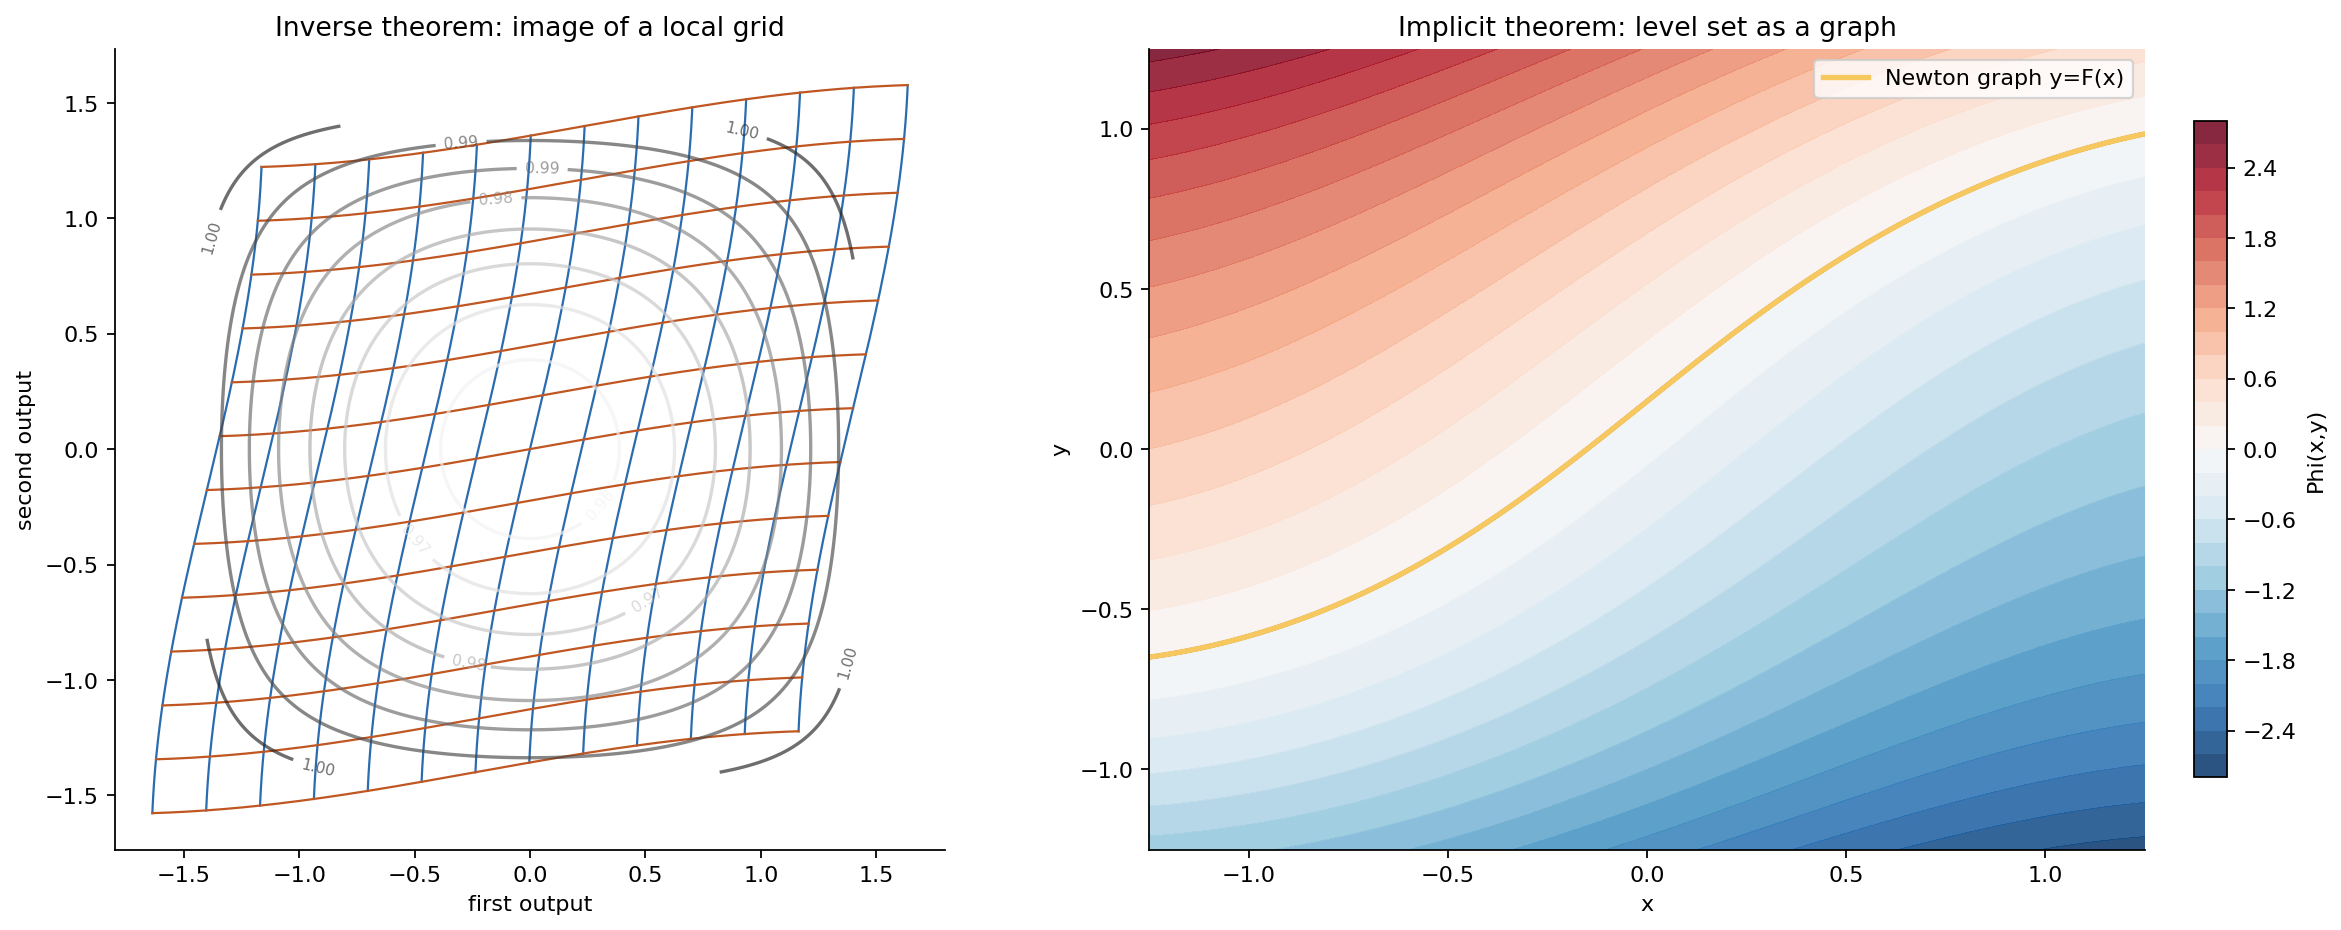

D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


,quantity,value
0,min_det_DF_on_box,9.568015e-01
1,max_det_DF_on_box,9.987520e-01
2,min_phi_y_on_rectangle,8.750205e-01
3,max_abs_implicit_graph_residual,1.387779e-16


In [11]:
def local_F(xx, yy):
    return xx + 0.24 * np.sin(yy), yy + 0.18 * np.sin(xx)


def det_local_F(xx, yy):
    return 1 - 0.24 * 0.18 * np.cos(xx) * np.cos(yy)


chart_grid = np.linspace(-1.4, 1.4, 13)
fine = np.linspace(-1.4, 1.4, 240)
XXc, YYc = np.meshgrid(fine, fine)
det_values = det_local_F(XXc, YYc)

phi_expr = y + sp.Rational(1, 4) * y**3 - sp.sin(x) - sp.Rational(1, 10) * x * y - sp.Rational(3, 20)
phi_y_expr = sp.diff(phi_expr, y)
phi = sp.lambdify((x, y), phi_expr, "numpy")
phi_y = sp.lambdify((x, y), phi_y_expr, "numpy")

x_graph = np.linspace(-1.25, 1.25, 240)
y_graph = np.sin(x_graph) + 0.15
for _ in range(10):
    y_graph = y_graph - phi(x_graph, y_graph) / phi_y(x_graph, y_graph)
implicit_residual = phi(x_graph, y_graph)

Ycont = np.linspace(-1.25, 1.25, 240)
Xcont, Ycont2 = np.meshgrid(x_graph, Ycont)
PHI = phi(Xcont, Ycont2)
PHIY = phi_y(Xcont, Ycont2)

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.7), constrained_layout=True)
for x0 in chart_grid:
    yy_line = np.linspace(-1.4, 1.4, 180)
    axes[0].plot(*local_F(np.full_like(yy_line, x0), yy_line), color="#2b6cb0", lw=1.0)
for y0 in chart_grid:
    xx_line = np.linspace(-1.4, 1.4, 180)
    axes[0].plot(*local_F(xx_line, np.full_like(xx_line, y0)), color="#c05621", lw=1.0)
cont = axes[0].contour(XXc, YYc, det_values, levels=8, cmap="Greys", alpha=0.65)
axes[0].clabel(cont, fontsize=7, fmt="%0.2f")
axes[0].set_aspect("equal")
axes[0].set_title("Inverse theorem: image of a local grid")
axes[0].set_xlabel("first output")
axes[0].set_ylabel("second output")

im = axes[1].contourf(Xcont, Ycont2, PHI, levels=30, cmap="RdBu_r", alpha=0.86)
axes[1].contour(Xcont, Ycont2, PHI, levels=[0], colors="black", linewidths=2.0)
axes[1].plot(x_graph, y_graph, color="#f6c85f", lw=2.4, label="Newton graph y=F(x)")
axes[1].set_title("Implicit theorem: level set as a graph")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].legend()
fig.colorbar(im, ax=axes[1], shrink=0.82, label="Phi(x,y)")

inverse_implicit_path = record_artifact(save_matplotlib(fig, FIGURES / "inverse-implicit-local-charts.png"))
plt.close(fig)

fig_html = go.Figure()
for x0 in chart_grid:
    yy_line = np.linspace(-1.4, 1.4, 160)
    xs, ys = local_F(np.full_like(yy_line, x0), yy_line)
    fig_html.add_trace(go.Scatter(x=xs, y=ys, mode="lines", line=dict(color="#2b6cb0", width=1.5), showlegend=False))
for y0 in chart_grid:
    xx_line = np.linspace(-1.4, 1.4, 160)
    xs, ys = local_F(xx_line, np.full_like(xx_line, y0))
    fig_html.add_trace(go.Scatter(x=xs, y=ys, mode="lines", line=dict(color="#c05621", width=1.5), showlegend=False))
fig_html.update_layout(title="Local diffeomorphism grid for F", xaxis_title="first output", yaxis_title="second output", width=780, height=620, yaxis_scaleanchor="x")
inverse_html_path = record_artifact(save_plotly_html(fig_html, HTML / "inverse-implicit-local-charts.html"))

inverse_rows = [
    {"quantity": "min_det_DF_on_box", "value": float(np.min(det_values))},
    {"quantity": "max_det_DF_on_box", "value": float(np.max(det_values))},
    {"quantity": "min_phi_y_on_rectangle", "value": float(np.min(PHIY))},
    {"quantity": "max_abs_implicit_graph_residual", "value": float(np.max(np.abs(implicit_residual)))},
]
inverse_table_path = record_artifact(save_csv(inverse_rows, TABLES / "inverse-implicit-local-chart-data.csv"))
inverse_checks = {
    "det_DF_formula": "1 - 0.0432*cos(x)*cos(y)",
    "min_det_DF_on_box": float(np.min(det_values)),
    "implicit_phi_y": str(phi_y_expr),
    "min_phi_y_on_rectangle": float(np.min(PHIY)),
    "max_abs_implicit_graph_residual": float(np.max(np.abs(implicit_residual))),
}
inverse_checks_path = record_check(save_json(inverse_checks, CHECKS / "inverse-implicit-local-chart-checks.json"))
assert inverse_checks["min_det_DF_on_box"] > 0.9
assert inverse_checks["min_phi_y_on_rectangle"] > 0.8
assert inverse_checks["max_abs_implicit_graph_residual"] < 1e-11
coverage["inverse function theorem"] = True
coverage["implicit function theorem"] = True
display_artifact(inverse_implicit_path, width=980)
display_artifact(inverse_html_path, width=820, height=620)
display(pd.DataFrame(inverse_rows))

## Applied Lab: How Large A Nonlinear Perturbation Can A Local Chart Tolerate?

The inverse function theorem is local. It does not say that a map with an invertible derivative at one point is globally invertible, and it does not give a universal neighborhood size. This lab sweeps a perturbation size in

`F_eps(x,y) = (x + eps sin y, y + eps sin x)`.

On the square shown here, the determinant is `1 - eps^2 cos x cos y`. Once `eps` passes `1`, the determinant can vanish near the origin, so the derivative hypothesis fails there. Before that threshold, the plotted minimum determinant is a numerical certificate that this square still has a local diffeomorphism test at every sampled point.

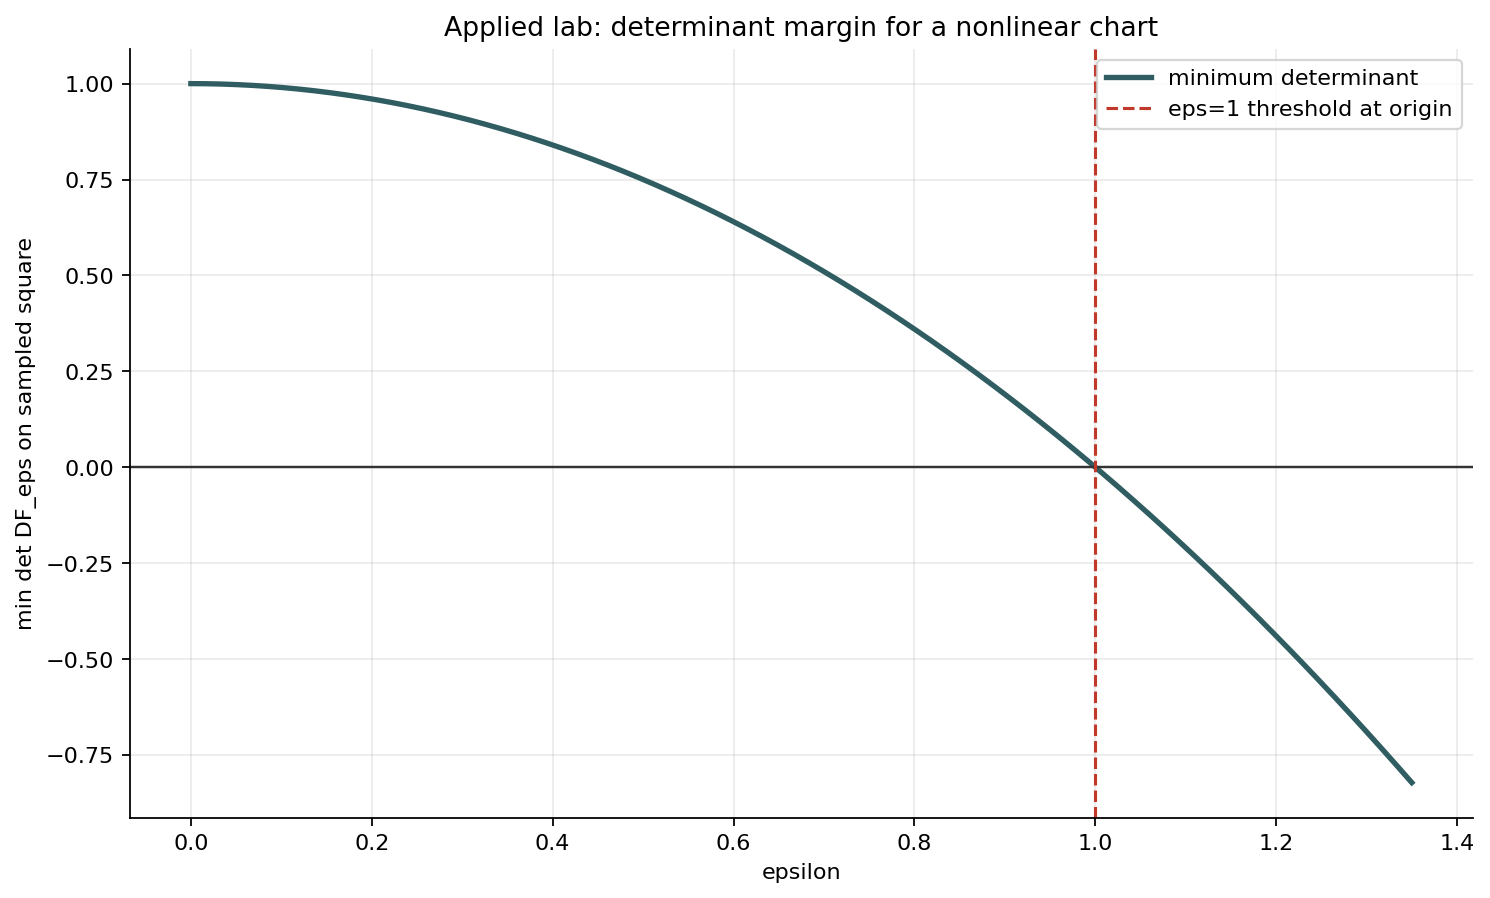

,epsilon,min_det_on_box,max_det_on_box,passes_positive_det_sample_test
0,0.000000,1.000000,1.000000,True
12,0.205063,0.957950,0.987724,True
24,0.410127,0.831801,0.950897,True
36,0.615190,0.621553,0.889518,True
48,0.820253,0.327206,0.803587,True
60,1.025316,-0.051241,0.693105,False
72,1.230380,-0.513787,0.558072,False


In [12]:
eps_values = np.linspace(0.0, 1.35, 80)
box_axis = np.linspace(-1.0, 1.0, 180)
BX, BY = np.meshgrid(box_axis, box_axis)
lab_rows = []
for eps in eps_values:
    det_eps = 1 - eps**2 * np.cos(BX) * np.cos(BY)
    lab_rows.append({"epsilon": float(eps), "min_det_on_box": float(np.min(det_eps)), "max_det_on_box": float(np.max(det_eps)), "passes_positive_det_sample_test": bool(np.min(det_eps) > 0)})

first_failure = next((row["epsilon"] for row in lab_rows if not row["passes_positive_det_sample_test"]), None)

fig, ax = plt.subplots(figsize=(9.2, 5.5), constrained_layout=True)
ax.plot(eps_values, [row["min_det_on_box"] for row in lab_rows], color="#2f5d62", lw=2.4, label="minimum determinant")
ax.axhline(0, color="#333333", lw=1.1)
ax.axvline(1.0, color="#c0392b", lw=1.4, ls="--", label="eps=1 threshold at origin")
ax.set_title("Applied lab: determinant margin for a nonlinear chart")
ax.set_xlabel("epsilon")
ax.set_ylabel("min det DF_eps on sampled square")
ax.legend()
ax.grid(True, alpha=0.25)

lab_path = record_artifact(save_matplotlib(fig, FIGURES / "applied-lab-inverse-chart-margin.png"))
plt.close(fig)
lab_table_path = record_artifact(save_csv(lab_rows, TABLES / "applied-lab-inverse-chart-margin.csv"))
lab_checks = {
    "first_sampled_failure_epsilon": first_failure,
    "last_positive_sample_epsilon": max(row["epsilon"] for row in lab_rows if row["passes_positive_det_sample_test"]),
    "threshold_expected_near": 1.0,
}
lab_checks_path = record_check(save_json(lab_checks, CHECKS / "applied-lab-inverse-chart-margin.json"))
assert 0.98 <= lab_checks["last_positive_sample_epsilon"] <= 1.02
display_artifact(lab_path, width=820)
display(pd.DataFrame(lab_rows).iloc[::12])

## Takeaways

- The total derivative is the best first-order local model; the useful quantity is the scaled remainder, not just the tangent plane picture.
- The Jacobian matrix is the coordinate form of the total derivative, and composition multiplies these local linear maps.
- Smoothness hypotheses do work: `C^2` gives equality of mixed partials, continuous parameter partials allow differentiation under an integral sign, and uniform derivative convergence is stronger than uniform function convergence.
- Riemann integration in this appendix is a geometric squeeze by partitions and measure-zero boundaries; change of variables adds the determinant because infinitesimal volume changes by that factor.
- The inverse and implicit function theorems convert derivative nonsingularity into local coordinates. Later manifold arguments repeatedly package this local Euclidean fact as charts, slices, submanifolds, and normal forms.

In [13]:
# final_sanity
required_artifacts = generated_artifacts + check_paths
assert_artifacts(required_artifacts, min_bytes=80)

png_stats = []
for path in generated_artifacts:
    if path.suffix.lower() == ".png":
        image = plt.imread(path)
        png_stats.append({"path": rel(path), "shape": list(image.shape), "std": float(np.std(image))})
        assert image.shape[0] >= 64 and image.shape[1] >= 64
        assert float(np.std(image)) > 0.005

coverage_missing = [name for name, done in coverage.items() if not done]
assert not coverage_missing, coverage_missing

core_assertions = {
    "total_derivative_remainder_decreases": total_checks["remainder_quotient_decreases"],
    "chain_rule_symbolic_residual_zero": chain_checks["chain_rule_matrix_residual"] == "Matrix([[0, 0], [0, 0]])",
    "mixed_partials_equal_for_smooth_example": mixed_checks["smooth_mixed_partial_residual"] == "0",
    "integral_interchange_residual_zero": integral_taylor_checks["integral_interchange_residual"] == "0",
    "taylor_error_below_sampled_bound": integral_taylor_checks["max_error_minus_bound"] <= 1e-10,
    "riemann_gap_decreases": riemann_checks["gap_decreases"],
    "change_of_variables_cell_error_small": change_checks["max_midpoint_relative_cell_error"] < 0.08,
    "vector_integral_estimate_holds": vector_checks["vector_integral_estimate_holds"],
    "lipschitz_samples_below_bound": vector_checks["lipschitz_samples_below_bound"],
    "uniform_good_derivatives_converge": uniform_checks["good_final_derivative_sup_error"] < 0.01,
    "uniform_bad_derivatives_do_not_converge": uniform_checks["bad_derivative_stays_large"],
    "inverse_det_bounded_away_from_zero": inverse_checks["min_det_DF_on_box"] > 0.9,
    "implicit_partial_bounded_away_from_zero": inverse_checks["min_phi_y_on_rectangle"] > 0.8,
}
assert all(core_assertions.values()), core_assertions

final_sanity = {
    "source_span": SOURCE_SPAN,
    "artifact_root": rel(ARTIFACT_ROOT),
    "artifact_count": len(generated_artifacts),
    "check_count": len(check_paths),
    "coverage": coverage,
    "core_assertions": core_assertions,
    "png_stats": png_stats,
    "artifacts": [rel(path) for path in generated_artifacts],
    "checks": [rel(path) for path in check_paths],
}
final_sanity_path = record_check(save_json(final_sanity, CHECKS / "final-sanity.json"))
assert_artifacts([final_sanity_path], min_bytes=200)
display_artifact(final_sanity_path)
print(json.dumps({"artifact_count": final_sanity["artifact_count"], "check_count": final_sanity["check_count"], "coverage_ok": all(coverage.values())}, indent=2))

`final-sanity.json`

{
  "artifact_count": 26,
  "check_count": 11,
  "coverage_ok": true
}
